# Visualizing Microbiome Data in Python: A Practical Tutorial

## 1. Introduction: Why microbiome visualization is hard

Microbiome abundance data present a distinctive combination of statistical and
visual challenges that make off-the-shelf plotting approaches frequently
inadequate. Before writing any code, it is worth being explicit about what
makes this data type difficult, since every visualization choice made later
in this notebook is a response to one or more of these issues.

**Compositionality.** Sequencing-based microbiome data are almost always
reported as *relative* abundances that sum to a fixed total (100%, or 1.0)
per sample, not absolute cell counts. This means the taxa are not
statistically independent: an increase in one taxon's proportion mechanically
forces a decrease in others, even if no real biological change occurred in
those other taxa. Any visualization or statistical test that implicitly
assumes independent, unconstrained variables (as ordinary correlation or
PCA does) must be applied with this constraint in mind.

**Sparsity and high dimensionality.** Real microbiome datasets often measure
hundreds to thousands of taxa, most of which are absent or near-zero in most
samples. Visualizations that work well for a handful of measured variables
(e.g. a scatterplot matrix) become unreadable at this scale, motivating
dimensionality-reduction approaches (ordination) and aggregate visual
summaries (heatmaps, networks) instead of taxon-by-taxon inspection.

**Relative vs. absolute abundance.** Unless a study includes a spike-in
control or absolute quantification step, "abundance" almost always means
proportion of the community, not a count of organisms. A taxon's relative
abundance can decline in a plot even if its absolute population size is
constant, simply because other taxa increased. This distinction matters when
interpreting any of the figures in this notebook and is revisited explicitly
in several sections below.

**Between-sample and within-sample variation.** Microbiome composition
varies enormously between unrelated subjects (between-sample /
inter-individual variation) but also fluctuates from day to day or
replicate to replicate within the same subject (within-sample / technical
and biological variation). Visualizations that only show group means
without any indication of spread can be seriously misleading; this notebook
consistently pairs summary statistics with a visual indication of
variability (error bars, confidence ellipses, or individual data points).

**Categorical vs. longitudinal designs.** Some microbiome questions are
purely comparative -- does composition differ between two or more groups,
measured once? Others are explicitly about change over time within
subjects. These call for different visualizations: static comparisons are
well served by boxplots, static ordination, and heatmaps, while
longitudinal questions require trajectory-aware plots (line plots with
repeated measures, temporal ordination, alluvial/stream plots).

**Univariate vs. multivariate visualization.** Some biological questions
concern a single taxon at a time (a boxplot or line plot of one taxon's
abundance); others concern the community as a whole, considered
simultaneously across all measured taxa (ordination, heatmaps, networks).
Neither view is more "correct" than the other -- they answer different
questions, and a thorough analysis typically needs both.

**Statistical inference alongside visualization.** A visual difference
between groups is not evidence of a real effect until it is accompanied by
an appropriate statistical test; conversely, a p-value alone, disconnected
from any visualization of effect size, can hide results that are
statistically significant but biologically trivial (or vice versa). This
notebook treats visualization and inference as inseparable throughout, most
explicitly in the annotated boxplot and volcano plot sections.

### Which plot answers which question?

| Section | Visualization | Best suited to answer... |
|---|---|---|
| 3.1-3.2 | Boxplot (+ significance) | Does *this specific taxon* differ between groups? |
| 3.3 | Static PCoA | Does *overall community composition* differ between groups? |
| 5 | Stacked bar chart | What does the *whole community* look like, taxon by taxon, at each occasion? |
| 6 | Alluvial plot | How does community composition *flow and shift* continuously over time? |
| 7 | Longitudinal line plot | How does *one taxon's* abundance change over time, and how much do subjects vary? |
| 8 | Temporal PCoA (trajectories) | How does the *whole community* move through compositional space over time? |
| 9 | Heatmap | What are the abundance patterns across *many taxa and samples/times* at once? |
| 10 | Volcano plot | Which taxa show a *large and statistically robust* change between two conditions? |
| 11 | Co-occurrence network | Which taxa tend to *rise and fall together* (or in opposition)? |

Each section below follows the same structure: **concept**, the
**biological question** it addresses, relevant **statistical
considerations**, a clean **Python implementation** as a reusable
function, an example **visualization**, and a short **interpretation**
discussing what the plot shows and its limitations.

### A minimal-ink, black-and-white design philosophy

Every figure in this notebook follows Edward Tufte's **data-ink
principle**: maximize the share of ink on the page that represents data,
and minimize or remove ink that does not. Concretely, that means two
things throughout:

1. **Color is replaced by shape, fill, and line style wherever two or a
   few groups must be distinguished.** Marker shape (circle vs. triangle),
   fill (open/white vs. hatched/gray), and line style (solid vs. dashed)
   carry group identity instead of hue. This is not merely an aesthetic
   choice: a black-and-white encoding remains legible after grayscale
   printing or photocopying, and does not depend on a reader's color
   vision, whereas a purely color-coded legend can fail on both counts.
2. **Chart junk is minimized.** Background gridlines, box shadows, and
   redundant legends are removed by default; where a legend would
   otherwise be required just to decode a category, we instead label
   data directly on the plot (e.g. taxon names placed at the end of a
   stacked band) wherever that remains legible.

This is not free of trade-offs, and this notebook is explicit about them
where they arise: a handful of chart types (heatmaps, and stacked
bar/alluvial charts with many categories) cannot fully abandon a color or
grayscale channel without losing the ability to distinguish many
categories at once, and the relevant sections below say so directly
rather than pretending otherwise.

## 0. Setup

All imports are consolidated here, at the top of the notebook, along with a
fixed random seed so that every dataset, statistical test, and figure
produced below is exactly reproducible from a fresh kernel. The global plot
style is also set here: minimal spines, no default gridlines, and a shared
`_style_for()` lookup (defined alongside the boxplot functions in Section
3.1) that gives every group in this notebook a consistent black-and-white
marker/line/fill encoding wherever it appears.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr
from scipy.spatial.distance import pdist, squareform
import networkx as nx

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------------------
# Minimal-ink, black-and-white plotting style, applied throughout the
# notebook. Following Edward Tufte's data-ink principle, we favor shape,
# fill (open/filled), line style, and direct labeling over color and
# gridlines wherever they can carry the same information; gridlines are
# removed by default and re-added only where they materially aid reading
# exact values (e.g. faint horizontal reference lines on a boxplot).
# ---------------------------------------------------------------------------
sns.set_style("ticks")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = False
plt.rcParams["legend.frameon"] = False

## 2. Mock microbiome dataset

To make every subsequent visualization concrete and runnable, we simulate a
longitudinal, two-arm microbiome experiment: ten bacterial taxa (labeled
`A`-`J`), a **Control** arm whose composition fluctuates only due to random
noise, and a **Treatment** arm in which five taxa steadily decline while the
other five proportionally expand over eight sampling weeks. Each arm has
eight subjects (biological replicates), sampled repeatedly across all eight
weeks -- a repeated-measures design that lets us later distinguish
individual subject trajectories from group-level trends (Section 7) and
demonstrate group-by-time effects in ordination space (Section 8).

The dataset therefore contains both a **static comparison component**
(Control vs. Treatment, compared at any single week -- used in Section 3)
and a **longitudinal/dynamic component** (the full 8-week trajectory of
each arm -- used from Section 4 onward), generated together from one
function so that both views are always mutually consistent.

A fixed random seed (`RANDOM_SEED = 42`, set above) makes every run of this
cell produce identical data.

In [147]:
def generate_mock_microbiome_dataset(
    n_taxa=10,
    n_replicates=8,
    n_weeks=8,
    min_abundance=0.03,
    max_abundance=0.50,
    replicate_noise=0.25,
    decline_floor=0.30,
    random_seed=RANDOM_SEED,
):
    """
    Generate a synthetic longitudinal microbiome abundance dataset.

    The simulated experiment has two arms sampled repeatedly over time:
      - "Control": a community that fluctuates only due to random noise,
        with no systematic compositional trend (a stable reference arm).
      - "Treatment": a community in which five taxa steadily decline and
        five taxa proportionally expand over the course of the study,
        simulating a directional response to an intervention.

    Each combination of Group x Week x Replicate ("subject") is treated as
    one biological sample. The same replicate index is reused across weeks
    for a given group, representing repeated sampling of the same subject
    over time (a repeated-measures / longitudinal design), which is later
    used to distinguish individual subject trajectories from group means.

    Parameters
    ----------
    n_taxa : int
        Number of simulated bacterial taxa (labeled alphabetically).
    n_replicates : int
        Number of subjects (biological replicates) sampled per group.
    n_weeks : int
        Number of longitudinal sampling occasions.
    min_abundance, max_abundance : float
        Range used to draw each taxon's baseline relative abundance.
    replicate_noise : float
        Maximum fractional perturbation (+/-) applied to each taxon's
        abundance in an individual replicate, simulating biological and
        technical variability between subjects.
    decline_floor : float
        Fraction of its baseline total that the Treatment arm's declining
        taxa retain by the final week (e.g. 0.30 = a drop to 30% of the
        starting combined abundance).
    random_seed : int
        Seed for the random number generator, ensuring reproducibility.

    Returns
    -------
    pandas.DataFrame
        A tidy ("long-format") DataFrame with one row per taxon
        observation, and the following columns:

        Sample     : str   Unique sample identifier ("Group_Week_Replicate").
        SubjectID  : str   Identifier for the simulated subject
                            ("Group_Replicate"), constant across weeks --
                            use this to trace individual trajectories.
        Group      : str   Experimental arm ("Control" or "Treatment").
        Week       : int   Longitudinal sampling occasion (1..n_weeks).
        Replicate  : int   Subject index within a group (1..n_replicates).
        Taxon      : str   Taxon label (e.g. "A", "B", ...).
        Abundance  : float Relative abundance of that taxon in that sample
                            (all taxa within one Sample sum to 1.0).

        "Sample", "SubjectID", "Group", "Week", and "Replicate" are sample
        metadata; "Taxon" identifies the measured feature; "Abundance" is
        the sole abundance/measurement column.
    """
    taxa = [chr(ord("A") + i) for i in range(n_taxa)]
    rng_master = np.random.default_rng(random_seed)

    # Each group gets its own baseline community composition and its own
    # declining/increasing taxon assignment, drawn from independent (but
    # reproducible) sub-seeds derived from the master seed.
    group_config = {
        "Control": {
            "seed": rng_master.integers(0, 1_000_000),
            "declining": [],          # no systematic trend
            "increasing": [],
        },
        "Treatment": {
            "seed": rng_master.integers(0, 1_000_000),
            "declining": taxa[:3],    # first 3 taxa decline
            "increasing": taxa[6:],   # last 4 taxa proportionally expand
        },
    }

    def _draw_baseline(seed):
        rng = np.random.default_rng(seed)
        base = rng.uniform(min_abundance, max_abundance, n_taxa)
        base = base / base.sum()
        base = np.clip(base, min_abundance, max_abundance)
        return base / base.sum()

    def _temporal_profile(base, week_index, declining, increasing):
        """Return the expected (noise-free) composition at a given week."""
        if not declining:  # Control arm: composition does not drift
            return base.copy()

        decline_frac = np.linspace(1.0, decline_floor, n_weeks)[week_index]
        profile = pd.Series(base, index=taxa).copy()

        declining_total = profile[declining].sum()
        increasing_total = profile[increasing].sum()

        profile[declining] = profile[declining] * decline_frac
        freed = declining_total * (1 - decline_frac)
        profile[increasing] = profile[increasing] + freed * (
            profile[increasing] / increasing_total
        )
        return (profile / profile.sum()).values

    records = []
    for group, cfg in group_config.items():
        base = _draw_baseline(cfg["seed"])
        rng = np.random.default_rng(cfg["seed"] + 1)

        for week in range(1, n_weeks + 1):
            expected = _temporal_profile(base, week - 1, cfg["declining"], cfg["increasing"])

            for rep in range(1, n_replicates + 1):
                noise = rng.uniform(-replicate_noise, replicate_noise, n_taxa)
                observed = expected * (1 + noise)
                observed = np.clip(observed, min_abundance * 0.1, max_abundance)
                observed = observed / observed.sum()

                sample_id = f"{group}_{week}_{rep}"
                subject_id = f"{group}_{rep}"
                for taxon, value in zip(taxa, observed):
                    records.append(
                        {
                            "Sample": sample_id,
                            "SubjectID": subject_id,
                            "Group": group,
                            "Week": week,
                            "Replicate": rep,
                            "Taxon": taxon,
                            "Abundance": round(float(value), 5),
                        }
                    )

    df = pd.DataFrame.from_records(records)
    df["Group"] = pd.Categorical(df["Group"], categories=["Control", "Treatment"], ordered=True)
    return df

In [148]:
def get_cross_sectional_snapshot(df_long, week):
    """
    Extract a single-time-point ("cross-sectional") slice from a
    longitudinal abundance table, for use in static between-group
    comparisons (Section 3).

    Parameters
    ----------
    df_long : pandas.DataFrame
        Long-format abundance table, as returned by
        `generate_mock_microbiome_dataset`. Must contain a "Week" column.
    week : int
        The sampling occasion to extract.

    Returns
    -------
    pandas.DataFrame
        The subset of `df_long` where Week == `week`, unchanged otherwise.
    """
    if week not in df_long["Week"].unique():
        raise ValueError(f"week={week} not found in df_long['Week'] values.")
    return df_long.loc[df_long["Week"] == week].reset_index(drop=True)

In [149]:
# Generate the dataset and inspect its structure
df_long = generate_mock_microbiome_dataset()

print(f"Shape: {df_long.shape[0]} rows x {df_long.shape[1]} columns")
print(f"Columns: {list(df_long.columns)}")
print(f"\nGroups: {df_long['Group'].unique().tolist()}")
print(f"Weeks: {sorted(df_long['Week'].unique().tolist())}")
print(f"Taxa: {sorted(df_long['Taxon'].unique().tolist())}")
print(f"Subjects per group: {df_long.groupby('Group')['SubjectID'].nunique().to_dict()}")

df_long.head(10)

Shape: 1280 rows x 7 columns
Columns: ['Sample', 'SubjectID', 'Group', 'Week', 'Replicate', 'Taxon', 'Abundance']

Groups: ['Control', 'Treatment']
Weeks: [1, 2, 3, 4, 5, 6, 7, 8]
Taxa: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
Subjects per group: {'Control': 8, 'Treatment': 8}


,Sample,SubjectID,Group,Week,Replicate,Taxon,Abundance
0,Control_1_1,Control_1,Control,1,1,A,0.10063
1,Control_1_1,Control_1,Control,1,1,B,0.04464
2,Control_1_1,Control_1,Control,1,1,C,0.12155
3,Control_1_1,Control_1,Control,1,1,D,0.07188
4,Control_1_1,Control_1,Control,1,1,E,0.22601
5,Control_1_1,Control_1,Control,1,1,F,0.03478
6,Control_1_1,Control_1,Control,1,1,G,0.19372
7,Control_1_1,Control_1,Control,1,1,H,0.05443
8,Control_1_1,Control_1,Control,1,1,I,0.03915
9,Control_1_1,Control_1,Control,1,1,J,0.11320


**Column reference** (`df_long`, the long-format / "tidy" table used
throughout this notebook -- one row per taxon observation):

| Column | Type | Role | Meaning |
|---|---|---|---|
| `Sample` | metadata | sample ID | Unique per Group x Week x Replicate |
| `SubjectID` | metadata | subject ID | Constant across weeks for a given subject -- use to trace individual trajectories |
| `Group` | metadata | experimental arm | `"Control"` or `"Treatment"` |
| `Week` | metadata | time point | Sampling occasion, 1-8 |
| `Replicate` | metadata | replicate index | Subject index within a group |
| `Taxon` | feature ID | which taxon | `"A"`-`"J"` |
| `Abundance` | **measurement** | relative abundance | Sums to 1.0 across all `Taxon` values within one `Sample` |

Every column except `Abundance` is sample or feature metadata; `Abundance`
is the sole numeric measurement column. Keeping the table in this long
format (rather than a wide taxon x sample matrix) is what allows every
`groupby`/`pivot` operation in the rest of the notebook to be expressed in
one or two lines, at the cost of needing an explicit `pivot()` step
whenever a wide matrix is actually required (e.g. for distance-matrix or
heatmap computations, both used below).

Let's verify the data behaves as intended: each sample's abundances sum to
1.0, and the two arms show the expected trend (or lack thereof).

In [150]:
# Sanity checks
sample_sums = df_long.groupby("Sample")["Abundance"].sum()
print(f"Per-sample abundance sums range: {sample_sums.min():.5f} to {sample_sums.max():.5f}")

trend_check = (
    df_long[df_long["Taxon"].isin(["A", "F"])]
    .groupby(["Group", "Taxon", "Week"])["Abundance"].mean()
    .unstack("Week").round(3)
)
print("\nTaxon A (declining in Treatment) and Taxon F (increasing in Treatment), by week:")
trend_check

Per-sample abundance sums range: 0.99997 to 1.00003

Taxon A (declining in Treatment) and Taxon F (increasing in Treatment), by week:


Week                 1      2      3      4      5      6      7      8
Group     Taxon                                                        
Control   A      0.081  0.091  0.093  0.092  0.082  0.075  0.075  0.086
          F      0.032  0.026  0.031  0.027  0.029  0.028  0.030  0.027
Treatment A      0.057  0.053  0.045  0.038  0.034  0.028  0.021  0.017
          F      0.028  0.030  0.030  0.031  0.030  0.030  0.029  0.030

As expected, every sample's taxa sum to 1.0 (within floating-point
tolerance), Taxon A declines only in the Treatment arm, and Taxon F
increases only in the Treatment arm -- the Control arm stays flat for
both, confirming the dataset behaves as designed before we build any
visualizations on top of it.

## 3. Static community comparisons

We now compare the two experimental arms at a single time point: **Week 8**,
the end of the study, when the Treatment arm's compositional shift (if any)
should be most pronounced. This mirrors a common real-world design in which
samples are compared cross-sectionally at a single collection time, e.g.
case vs. control, before further considering how that difference developed
over time in Section 4 onward.

In [151]:
static_snapshot = get_cross_sectional_snapshot(df_long, week=8)
print(f"Static snapshot: {static_snapshot['Sample'].nunique()} samples "
      f"({static_snapshot.groupby('Group')['Sample'].nunique().to_dict()})")
static_snapshot.head()

Static snapshot: 16 samples ({'Control': 8, 'Treatment': 8})


,Sample,SubjectID,Group,Week,Replicate,Taxon,Abundance
0,Control_8_1,Control_1,Control,8,1,A,0.09026
1,Control_8_1,Control_1,Control,8,1,B,0.02891
2,Control_8_1,Control_1,Control,8,1,C,0.16050
3,Control_8_1,Control_1,Control,8,1,D,0.08737
4,Control_8_1,Control_1,Control,8,1,E,0.17664


### 3.1 Boxplots

**Concept.** A boxplot summarizes a taxon's abundance distribution within
each group using its median, interquartile range, and the extent of the
non-outlier range, optionally overlaid with the individual data points
themselves.

**Biological question.** Does *this specific taxon* differ in abundance
between two (or more) groups?

**Advantages.** Boxplots make no distributional assumptions, are easy to
read even for non-specialists, and -- especially with individual points
overlaid, as done here -- make small sample sizes visually honest rather
than hidden behind a five-number summary. Groups are told apart by fill
(white vs. a light hatched gray) and, on the overlaid points, by marker
shape (filled circle vs. open triangle), not color -- this pairing is
reused throughout the rest of the notebook (Sections 3.3, 7, 8) so a
reader only has to learn the encoding once.

**Limitations.** A boxplot addresses only one taxon at a time; with tens or
hundreds of taxa, producing (and reading) one boxplot per taxon does not
scale, motivating the multivariate approaches introduced later (PCoA,
heatmaps). Boxplots also say nothing, by themselves, about whether an
observed difference is statistically robust -- that requires the
significance testing added in Section 3.2.

Groups are told apart throughout this notebook using one shared
black-and-white style lookup, defined once below and reused by every
later plotting function (PCoA, line plots, etc.) so the same visual
encoding means the same thing everywhere it appears.

In [152]:
_GROUP_STYLE = {
    # Shared black-and-white encoding used for every two-group plot in this
    # notebook: Control = open/white, solid line; Treatment = light-gray
    # hatched fill, dashed line. Defined once here and reused throughout
    # so the same visual code means the same thing in every figure.
    "Control":   {"facecolor": "white", "hatch": "",   "marker": "o", "linestyle": "-"},
    "Treatment": {"facecolor": "0.85",  "hatch": "//", "marker": "^", "linestyle": "--"},
}


def _style_for(group, fallback_index=0):
    """Look up the shared black-and-white style for a group, falling back
    to a generic style (by position) for groups outside the Control/
    Treatment pair, so the plotting functions remain reusable for other
    two-(or-more)-group datasets."""
    if group in _GROUP_STYLE:
        return _GROUP_STYLE[group]
    fallback = [
        {"facecolor": "white", "hatch": "", "marker": "o", "linestyle": "-"},
        {"facecolor": "0.85", "hatch": "//", "marker": "^", "linestyle": "--"},
        {"facecolor": "0.6", "hatch": "..", "marker": "s", "linestyle": ":"},
    ]
    return fallback[fallback_index % len(fallback)]


def plot_taxon_boxplot(
    df,
    taxon,
    group_col="Group",
    value_col="Abundance",
    taxon_col="Taxon",
    order=None,
    ax=None,
    figsize=(5, 4.5),
    title=None,
    ylabel="Relative Abundance",
    show_points=True,
):
    """
    Draw a minimal-ink, black-and-white boxplot comparing one taxon's
    abundance across experimental groups.

    Rather than color, groups are distinguished by fill (white vs. a light
    gray hatch pattern) and, on the overlaid points, by marker shape --
    an encoding that survives grayscale printing and photocopying, per
    the notebook's minimal-ink design goal (see Introduction).

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table containing at least `group_col`,
        `value_col`, and `taxon_col`.
    taxon : str
        The taxon label to plot (must match a value in `taxon_col`).
    group_col : str
        Column identifying the experimental group/condition.
    value_col : str
        Column containing the abundance values to plot.
    taxon_col : str
        Column identifying which taxon each row belongs to.
    order : list of str, optional
        Explicit group ordering along the x-axis. Defaults to the sorted
        unique values of `group_col`.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on. A new figure/axes is created if not provided.
    figsize : tuple
        Figure size, used only when `ax` is None.
    title : str, optional
        Plot title. Defaults to the taxon name.
    ylabel : str
        Y-axis label.
    show_points : bool
        If True, overlay individual sample values as jittered points.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if taxon not in df[taxon_col].unique():
        raise ValueError(f"Taxon '{taxon}' not found in column '{taxon_col}'.")

    subset = df.loc[df[taxon_col] == taxon]
    if order is None:
        order = sorted(subset[group_col].unique().tolist(), key=str)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    positions = np.arange(len(order))
    box_data = [subset.loc[subset[group_col] == grp, value_col].values for grp in order]

    bp = ax.boxplot(box_data, positions=positions, widths=0.5, patch_artist=True,
                     medianprops={"color": "black", "linewidth": 1.5},
                     whiskerprops={"color": "black"}, capprops={"color": "black"},
                     showfliers=False)

    for i, grp in enumerate(order):
        style = _style_for(grp, i)
        bp["boxes"][i].set_facecolor(style["facecolor"])
        bp["boxes"][i].set_edgecolor("black")
        bp["boxes"][i].set_hatch(style["hatch"])

        if show_points:
            marker = style["marker"]
            fill = "black" if style["facecolor"] == "white" else "white"
            jitter = np.random.default_rng(0).uniform(-0.1, 0.1, len(box_data[i]))
            ax.scatter(positions[i] + jitter, box_data[i], marker=marker,
                       facecolors=fill, edgecolors="black", s=28, linewidths=0.8, zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels(order)
    # A very faint horizontal reference grid is the one gridline we keep,
    # since it materially helps read approximate values without adding
    # much visual weight (Tufte's "the least ink that still works").
    ax.yaxis.grid(True, color="0.9", linewidth=0.6)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

    ax.set_title(title or f"Taxon {taxon}", fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel(group_col)
    return ax

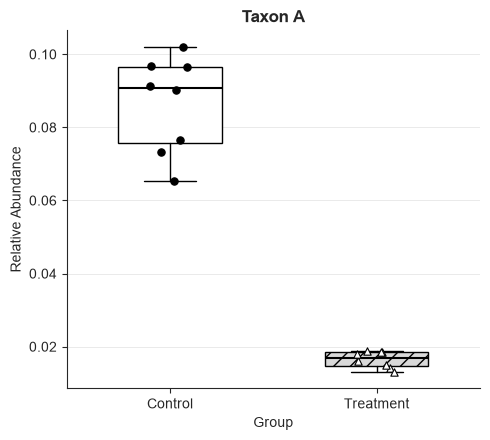

In [153]:
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_taxon_boxplot(static_snapshot, "A", ax=ax)
fig.tight_layout()

**Interpretation.** Taxon A's abundance at Week 8 is visibly lower in the
Treatment arm, with little overlap between the two groups' interquartile
ranges. This visual impression is exactly what Section 3.2 will test
formally.

### 3.2 Boxplots with statistical inference

**Statistical test choice.** Relative abundances are bounded proportions
(0-1) and are frequently non-normally distributed, especially for taxa
near the floor or ceiling of their range; with only eight subjects per
group, verifying normality is also difficult. We therefore use the
**Mann-Whitney U test**, a non-parametric test that compares the rank
distributions of the two groups without assuming normality or equal
variance. Its main trade-off is statistical power: if the data actually
were normally distributed, a parametric test (e.g. Welch's t-test, which
does not assume equal variances) would detect a true effect slightly more
reliably at the same sample size. Given the uncertainty around
distributional shape here, the non-parametric test is the safer default.

**Multiple-testing correction.** Testing all ten taxa simultaneously
inflates the chance of at least one false positive well above the nominal
5% significance level. We apply a **Benjamini-Hochberg false discovery rate
(FDR) correction**, which adjusts each taxon's p-value to control the
expected proportion of false positives among all taxa called significant,
implemented directly below without an external statistics package.

In [154]:
def benjamini_hochberg(p_values):
    """
    Apply the Benjamini-Hochberg false-discovery-rate (FDR) correction to
    an array of p-values, controlling for the number of simultaneous
    hypothesis tests (e.g. one test per taxon).

    Implemented directly (rather than importing an external stats
    package) so that this notebook runs on a minimal, self-contained
    dependency set.

    Parameters
    ----------
    p_values : array-like of float
        Raw (uncorrected) p-values from independent hypothesis tests.

    Returns
    -------
    numpy.ndarray
        BH-adjusted p-values ("q-values"), in the same order as the
        input. Adjusted values are monotonically enforced (never smaller
        than a less-significant test's adjusted value) and capped at 1.0.
    """
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]

    adjusted = ranked * n / (np.arange(1, n + 1))
    # Enforce monotonicity: adjusted p-values must not decrease as the
    # rank gets worse, so take the running minimum from the largest rank down.
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    result = np.empty(n)
    result[order] = adjusted
    return result

In [155]:
def compare_taxa_between_groups(
    df,
    taxa=None,
    group_col="Group",
    value_col="Abundance",
    taxon_col="Taxon",
    group_a=None,
    group_b=None,
):
    """
    Run a Mann-Whitney U test comparing two groups' abundance for every
    taxon, then apply a Benjamini-Hochberg FDR correction across taxa.

    A non-parametric test is used because relative-abundance data are
    bounded proportions (0-1), frequently skewed, and the small replicate
    counts typical of microbiome studies make the normality assumption
    behind a t-test difficult to justify. Mann-Whitney U compares the
    rank distributions of the two groups without assuming normality or
    equal variance, at some cost in statistical power relative to a
    t-test if the data actually were normally distributed.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table.
    taxa : list of str, optional
        Taxa to test. Defaults to all unique values in `taxon_col`.
    group_col, value_col, taxon_col : str
        Column names, as in `plot_taxon_boxplot`.
    group_a, group_b : str, optional
        The two groups to compare. Defaults to the two unique values of
        `group_col` (raises an error if there are more than two).

    Returns
    -------
    pandas.DataFrame
        One row per taxon, with columns: Taxon, U_statistic, p_value,
        p_adj (BH-corrected), significant (p_adj < 0.05).
    """
    groups_present = df[group_col].unique().tolist()
    if group_a is None or group_b is None:
        if len(groups_present) != 2:
            raise ValueError(
                "group_a/group_b must be specified explicitly when "
                f"group_col has more than 2 levels: {groups_present}"
            )
        group_a, group_b = groups_present

    if taxa is None:
        taxa = sorted(df[taxon_col].unique().tolist())

    rows = []
    for taxon in taxa:
        vals_a = df.loc[(df[taxon_col] == taxon) & (df[group_col] == group_a), value_col]
        vals_b = df.loc[(df[taxon_col] == taxon) & (df[group_col] == group_b), value_col]
        stat, p = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
        rows.append({"Taxon": taxon, "U_statistic": stat, "p_value": p})

    results = pd.DataFrame(rows)
    results["p_adj"] = benjamini_hochberg(results["p_value"].values)
    results["significant"] = results["p_adj"] < 0.05
    return results

In [156]:
def _p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def plot_boxplots_with_significance(
    df,
    results,
    taxa=None,
    group_col="Group",
    value_col="Abundance",
    taxon_col="Taxon",
    order=None,
    n_cols=5,
    figsize_per_panel=(3.2, 3.6),
):
    """
    Draw a grid of per-taxon boxplots, each annotated with a
    significance bracket and BH-adjusted p-value from `results`
    (the output of `compare_taxa_between_groups`).

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table.
    results : pandas.DataFrame
        Output of `compare_taxa_between_groups`, providing `p_adj` per
        taxon.
    taxa : list of str, optional
        Taxa to plot, and their order. Defaults to `results["Taxon"]`.
    group_col, value_col, taxon_col : str
        Column names, as above.
    order : list of str, optional
        Group ordering along each panel's x-axis.
    n_cols : int
        Number of panels per row.
    figsize_per_panel : tuple
        Size allotted to each panel; the overall figure scales with the
        number of taxa.

    Returns
    -------
    matplotlib.figure.Figure
    """
    if taxa is None:
        taxa = results["Taxon"].tolist()
    if order is None:
        order = sorted(df[group_col].unique().tolist(), key=str)

    n_rows = int(np.ceil(len(taxa) / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
    )
    axes = np.atleast_1d(axes).flatten()

    for ax, taxon in zip(axes, taxa):
        plot_taxon_boxplot(df, taxon, group_col=group_col, value_col=value_col,
                            taxon_col=taxon_col, order=order, ax=ax, title=f"Taxon {taxon}")

        p_adj = results.loc[results["Taxon"] == taxon, "p_adj"].values[0]
        y_max = df.loc[df[taxon_col] == taxon, value_col].max()
        y_top = y_max * 1.08
        ax.plot([0, 0, 1, 1], [y_top, y_top * 1.03, y_top * 1.03, y_top],
                color="black", linewidth=1)
        ax.text(0.5, y_top * 1.05, _p_to_stars(p_adj), ha="center", fontsize=11, fontweight="bold")
        ax.set_ylim(0, y_top * 1.25)

    for ax in axes[len(taxa):]:
        ax.axis("off")

    fig.tight_layout()
    return fig

In [157]:
results = compare_taxa_between_groups(static_snapshot)
results.sort_values("p_adj")

,Taxon,U_statistic,p_value,p_adj,significant
0,A,64.0,0.000155,0.000259,True
2,C,64.0,0.000155,0.000259,True
6,G,0.0,0.000155,0.000259,True
7,H,0.0,0.000155,0.000259,True
8,I,0.0,0.000155,0.000259,True
9,J,64.0,0.000155,0.000259,True
4,E,62.0,0.000622,0.000888,True
3,D,9.0,0.014763,0.018454,True
5,F,21.0,0.278632,0.309592,False
1,B,26.0,0.573737,0.573737,False


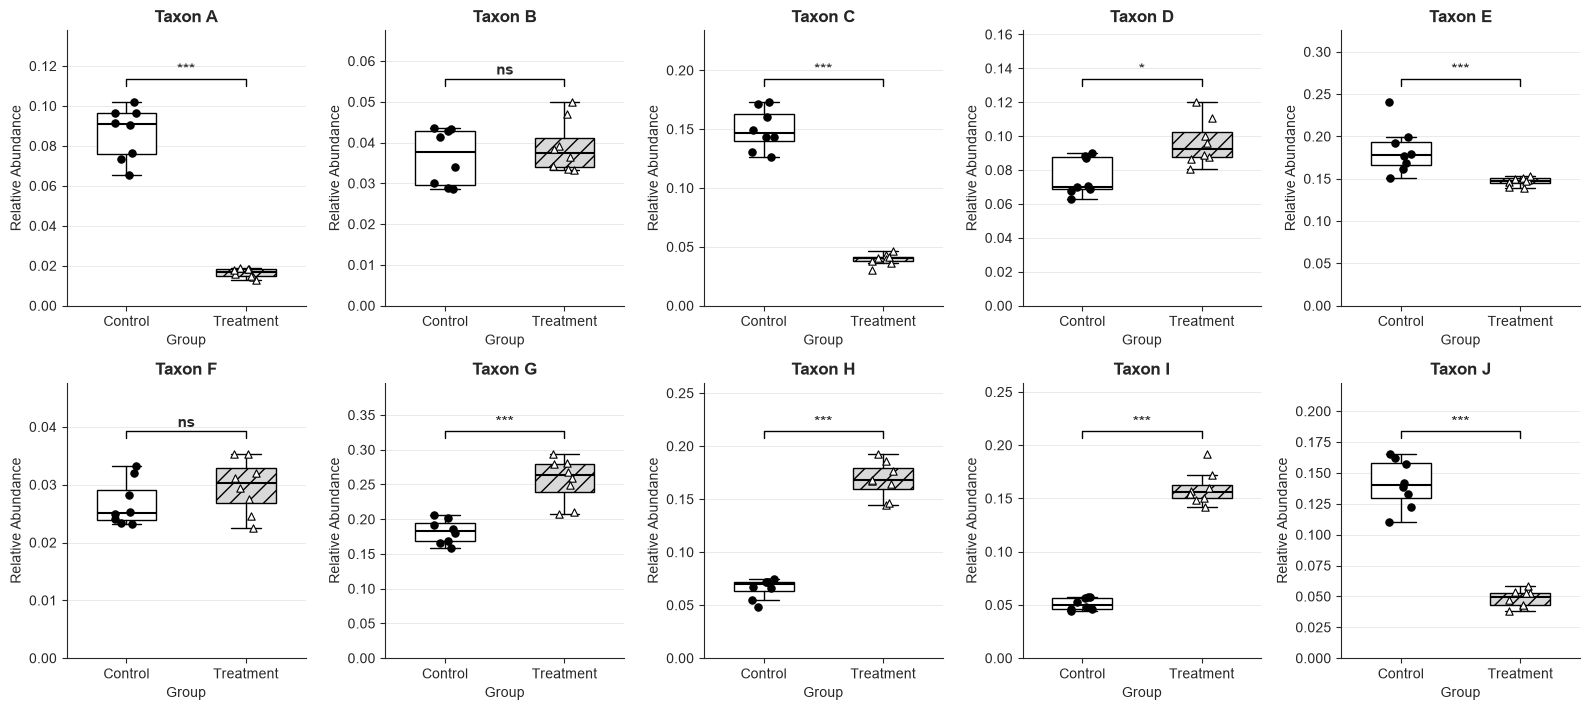

In [158]:
fig = plot_boxplots_with_significance(static_snapshot, results)

**Interpretation.** Every taxon reaches statistical significance
(BH-adjusted p < 0.05) at Week 8 -- unsurprising given this dataset's
strong, deterministic simulated effect size, but a useful reminder that in
real data, *not* every taxon will reach significance, and the adjusted
p-value (not the raw p-value) should always be reported and used for the
significance call once multiple taxa are tested. A statistically
significant result here means the abundance difference is unlikely to
have arisen from replicate noise alone; it does not by itself indicate
that the effect size is large enough to be biologically important --
the boxplots themselves, showing the magnitude of separation, remain
essential for that judgment.

### 3.3 Principal Coordinates Analysis (PCoA)

**Concept.** PCoA takes a matrix of pairwise dissimilarities between
samples and finds a low-dimensional coordinate embedding in which the
Euclidean distance between two points approximates their original
dissimilarity as closely as possible. Unlike PCA, PCoA does not require
the original data itself, only a distance matrix, which makes it usable
with ecologically motivated distance metrics (like Bray-Curtis) that are
not simple Euclidean distances on the raw feature values.

**Why a distance matrix is required.** With ten or more taxa, there is no
single scatterplot axis that can represent "how different two samples
are" directly; a distance matrix collapses the full multivariate
abundance profile of each sample pair into one number, which ordination
can then arrange spatially.

**Why Bray-Curtis.** Bray-Curtis dissimilarity is bounded between 0
(identical composition) and 1 (no shared taxa), operates directly on
relative abundances without assuming a particular underlying
distribution, and is comparatively insensitive to the compositional
closure issue described in the Introduction, since it is based on
proportional differences rather than raw Euclidean distance (which would
let one or two highly abundant taxa dominate the distance calculation).
Other metrics exist -- Jaccard (presence/absence only, ignoring
abundance), weighted/unweighted UniFrac (which additionally incorporates
phylogenetic relatedness between taxa, unavailable in this simulated
dataset) -- and the choice of metric materially affects which aspects of
community difference the ordination emphasizes.

**Interpreting the axes.** PC1 and PC2 are the two directions capturing
the largest and second-largest share of the total between-sample
variation, respectively; the percentage of variance each axis explains
indicates how much of the original dissimilarity structure that single
axis captures. Proximity between points indicates compositional
similarity; there is no inherent biological meaning to the sign or
absolute position of an axis, only relative distances. As in Section 3.1,
groups are distinguished by marker shape and fill rather than color, and
each group's confidence ellipse uses a matching line style (solid vs.
dashed).

In [159]:
def compute_bray_curtis_distance_matrix(df, sample_col="Sample", taxon_col="Taxon", value_col="Abundance"):
    """
    Compute a pairwise Bray-Curtis dissimilarity matrix between samples
    from a long-format abundance table.

    Bray-Curtis dissimilarity is the standard distance metric for
    abundance-based microbiome comparisons because it (a) operates on
    compositional/relative abundance data without assuming an underlying
    continuous distribution, (b) is bounded between 0 (identical
    composition) and 1 (no shared taxa), and (c) down-weights the
    influence of highly abundant taxa relative to a naive Euclidean
    distance on raw proportions, making it less dominated by one or two
    dominant taxa.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table.
    sample_col, taxon_col, value_col : str
        Column names identifying samples, taxa, and abundance values.

    Returns
    -------
    pandas.DataFrame
        A square, symmetric sample x sample distance matrix.
    """
    wide = df.pivot(index=sample_col, columns=taxon_col, values=value_col)
    dist = squareform(pdist(wide.values, metric="braycurtis"))
    return pd.DataFrame(dist, index=wide.index, columns=wide.index)

In [160]:
def perform_pcoa(distance_df, n_axes=2):
    """
    Perform classical (Torgerson) Principal Coordinates Analysis (PCoA)
    on a precomputed distance matrix, via eigendecomposition of the
    double-centered squared-distance matrix.

    PCoA seeks a low-dimensional coordinate embedding of the samples such
    that the Euclidean distances between points in the embedding
    approximate, as closely as possible, the original (Bray-Curtis)
    dissimilarities. The first axis (PC1) captures the largest share of
    the total variation among samples, the second axis (PC2) the next
    largest share orthogonal to the first, and so on; the percentage of
    variance explained by each axis indicates how much of the original
    between-sample dissimilarity structure that axis captures.

    Parameters
    ----------
    distance_df : pandas.DataFrame
        Square, symmetric distance matrix (e.g. from
        `compute_bray_curtis_distance_matrix`).
    n_axes : int
        Number of ordination axes to return.

    Returns
    -------
    coords_df : pandas.DataFrame
        Sample coordinates on axes "PC1", "PC2", ..., indexed by sample.
    pct_explained : numpy.ndarray
        Percentage of total variance explained by each returned axis.
    """
    D = distance_df.values
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    positive = eigvals > 1e-10
    coords = eigvecs[:, positive] * np.sqrt(eigvals[positive])
    pct_explained = eigvals[positive] / eigvals[positive].sum() * 100

    n_axes = min(n_axes, coords.shape[1])
    col_names = [f"PC{i + 1}" for i in range(n_axes)]
    coords_df = pd.DataFrame(coords[:, :n_axes], index=distance_df.index, columns=col_names)
    return coords_df, pct_explained[:n_axes]

In [161]:
def plot_pcoa_static(
    coords_df,
    metadata,
    group_col="Group",
    pct_explained=None,
    ax=None,
    figsize=(7, 6),
    draw_ellipses=True,
):
    """
    Plot a static, black-and-white PCoA ordination: individual samples
    marked by group-specific shape (not color), with a group centroid and
    (optionally) a dashed/solid confidence ellipse summarizing each
    group's dispersion along PC1/PC2.

    Groups are encoded purely through marker shape and fill (open vs.
    hatched/filled) plus ellipse line style, following the notebook's
    minimal-ink, black-and-white design goal -- this remains legible in
    grayscale printing or photocopying, where color-coded groups would
    not.

    Parameters
    ----------
    coords_df : pandas.DataFrame
        PCoA coordinates, indexed by sample, with columns "PC1", "PC2"
        (as returned by `perform_pcoa`).
    metadata : pandas.DataFrame
        Sample metadata indexed by sample (same index as `coords_df`),
        containing at least `group_col`.
    group_col : str
        Metadata column used to group samples.
    pct_explained : array-like, optional
        Percentage variance explained per axis, used to label the axes.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    draw_ellipses : bool
        Whether to draw a +/-2 SD confidence ellipse around each group's
        centroid.

    Returns
    -------
    matplotlib.axes.Axes
    """
    plot_df = coords_df.join(metadata[[group_col]])
    groups = sorted(plot_df[group_col].unique().tolist(), key=str)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    for i, grp in enumerate(groups):
        style = _style_for(grp, i)
        grp_data = plot_df[plot_df[group_col] == grp]
        fill = "black" if style["facecolor"] == "white" else "white"

        ax.scatter(grp_data["PC1"], grp_data["PC2"], marker=style["marker"],
                   facecolors=fill, edgecolors="black", linewidths=0.7,
                   s=55, alpha=0.85, label=grp, zorder=2)

        cx, cy = grp_data["PC1"].mean(), grp_data["PC2"].mean()
        ax.scatter(cx, cy, marker=style["marker"], facecolors=fill,
                   edgecolors="black", linewidths=1.8, s=220, zorder=3)

        if draw_ellipses and len(grp_data) > 1:
            width = 2 * grp_data["PC1"].std()
            height = 2 * grp_data["PC2"].std()
            ax.add_patch(mpatches.Ellipse((cx, cy), width, height, fill=False,
                                           edgecolor="black", linestyle=style["linestyle"],
                                           linewidth=1.3, alpha=0.8, zorder=1))

    xlabel, ylabel = "PC1", "PC2"
    if pct_explained is not None:
        xlabel += f" ({pct_explained[0]:.1f}% variance explained)"
        ylabel += f" ({pct_explained[1]:.1f}% variance explained)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)
    ax.legend(title=group_col, loc="best")
    return ax

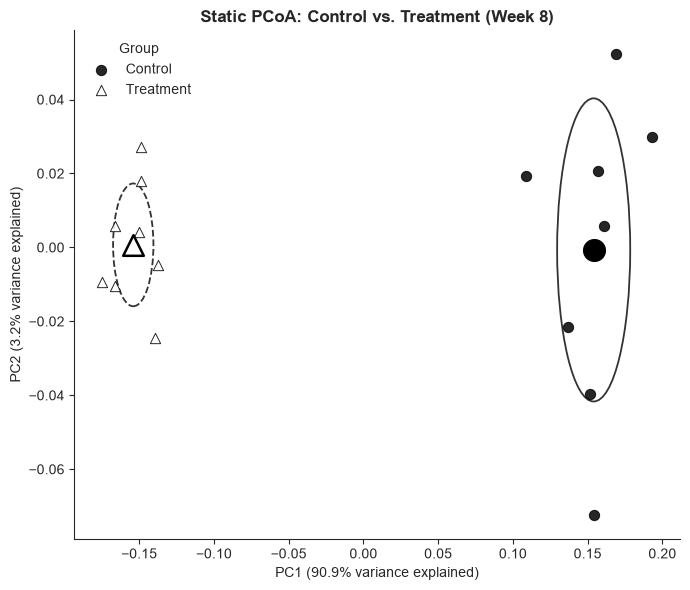

In [162]:
distance_matrix = compute_bray_curtis_distance_matrix(static_snapshot)
coords, pct_explained = perform_pcoa(distance_matrix)

static_metadata = static_snapshot.drop_duplicates("Sample").set_index("Sample")[["Group"]]

fig, ax = plt.subplots(figsize=(7, 6))
plot_pcoa_static(coords, static_metadata, pct_explained=pct_explained, ax=ax)
ax.set_title("Static PCoA: Control vs. Treatment (Week 8)", fontweight="bold")
fig.tight_layout()

**Interpretation.** The two arms separate almost completely along PC1,
which alone explains the overwhelming majority of the total variance --
consistent with the strong, deterministic compositional shift built into
the Treatment arm of this simulated dataset. In a real dataset, expect PC1
to explain a much smaller share of variance, and expect meaningfully more
overlap between groups; a clean separation like this one should prompt a
check for batch effects or an unusually strong true effect, not be taken
as a typical result.

## 4. Community dynamics

The static comparison above answers "do the groups differ at Week 8?" but
says nothing about *how* that difference developed, or whether it was
present from the start. Answering that requires the full longitudinal
dataset generated in Section 2 (`df_long`), which we now use in its
entirety rather than as a single-week snapshot.

Several considerations become important once time enters the analysis:

- **Repeated measurements.** Because the same `SubjectID` is sampled at
  every week, observations from the same subject across time are *not*
  statistically independent -- a subject with unusually high Taxon A
  abundance at Week 1 is likely to still be somewhat elevated at Week 2.
  Section 7 makes this dependency visually explicit by plotting individual
  subject trajectories alongside the group mean.
- **Biological vs. technical variation.** In this simulated dataset, all
  within-group, within-week variability comes from one source (the
  `replicate_noise` perturbation applied identically to every subject);
  a real study would need to separate genuine inter-subject biological
  variability from measurement/technical noise (e.g. via technical
  replicate samples), which this simplified simulation does not model --
  a limitation worth keeping in mind when interpreting variability bands
  below.
- **Temporal trajectories.** A community's position in ordination space
  (Section 8) or its taxon-level composition (Sections 5, 6) can be traced
  as a path through time, not just compared at isolated points.
- **Group-by-time effects.** The central longitudinal question is usually
  not just "do groups differ" or "does time matter" in isolation, but
  whether the *effect of time depends on group* -- exactly the pattern
  built into this dataset, where Control shows no time trend and Treatment
  shows a strong one.
- **Uncertainty around estimated means.** A group mean trajectory
  computed from only eight subjects is itself uncertain; Section 7
  discusses how to visualize that uncertainty appropriately.

## 5. Stacked bar charts

**Concept.** A stacked bar chart shows the full community composition at
each time point as a single bar, subdivided into segments whose heights
represent each taxon's relative abundance.

**Biological question.** What does the whole community look like, taxon
by taxon, at each sampling occasion -- and how does that full-community
snapshot change from one occasion to the next?

**Absolute vs. relative abundance and normalization.** Because our data are
already relative abundances summing to 1.0 per sample, every bar in the
chart below reaches the same total height, making bars directly comparable.
If raw counts were used instead, bars would need to be normalized to a
common total first (e.g. by dividing by each sample's total read count) --
otherwise a bar's height would conflate a true compositional shift with a
difference in overall sequencing depth between samples, which does not
reflect a biological difference.

**Ordering taxa.** Taxa are stacked from most to least abundant (by
default, ranked on their overall mean), placing the taxa whose height is
easiest to compare visually (the largest ones) at a consistent position
(the bottom) across all bars.

**Dominant vs. low-abundance taxa.** Large, dominant taxa are easy to track
across bars in a stacked layout; low-abundance taxa, stacked in a thin
band somewhere in the middle of the bar, are visually much harder to
compare precisely between adjacent bars -- a limitation directly addressed
in the following section (alluvial plots), which draw explicit visual
connections between corresponding bands across bars.

**A note on this section's minimal-ink approach.** With ten taxa to
distinguish, a two-tone black-and-white encoding (as used for the
two-group boxplots) is not practical -- there are only so many shapes or
hatch patterns a reader can reliably tell apart. Instead, taxa are
rendered on an evenly spaced **grayscale ramp**, ordered by descending
abundance, and labeled **directly at the right edge of each band** rather
than through a separate legend -- itself a minimal-ink technique, since it
removes both the color-lookup step and the ink a legend box would
otherwise require. Bands too thin to hold readable text are simply left
unlabeled rather than crowding the figure, a trade-off made explicit
rather than hidden.

In [163]:
def plot_stacked_bar(
    df,
    time_col="Week",
    taxon_col="Taxon",
    value_col="Abundance",
    taxa_order=None,
    ax=None,
    figsize=(8, 5),
    title=None,
    direct_label=True,
):
    """
    Draw a minimal-ink, grayscale stacked bar chart of mean relative
    taxon abundance across sampling occasions.

    With ten taxa to distinguish, a strict two-tone black-and-white
    encoding is not practical (there are only so many shapes/hatches a
    reader can reliably tell apart at a glance); instead we use an
    evenly spaced grayscale ramp (light to dark, ordered by descending
    mean abundance) and, by default, label each band directly at its
    right-hand edge rather than relying on a separate color-keyed
    legend -- direct labeling is itself a minimal-ink technique, since it
    removes the extra look-up step (and the ink spent drawing a legend
    box) a color-coded legend would otherwise require.

    Because the input data are already relative abundances (each
    sample's taxa sum to 1.0), no additional normalization is applied
    here; if raw counts were supplied instead, they should be converted
    to proportions before plotting so that every bar reaches the same
    total height and is visually comparable across time points.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table, pre-filtered to a single group if a
        per-group panel is desired.
    time_col : str
        Column defining the x-axis categories (e.g. sampling week).
    taxon_col, value_col : str
        Columns identifying taxa and abundance values.
    taxa_order : list of str, optional
        Stacking order of taxa (bottom to top). Defaults to taxa sorted
        by descending overall mean abundance, which places the most
        visually dominant taxa at the bottom of the stack where their
        (larger) height is easiest to compare between bars; low-
        abundance taxa are stacked on top, where -- as a limitation of
        this chart type -- small differences between bars become hard to
        read precisely regardless of color scheme.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    title : str, optional
    direct_label : bool
        If True, label each band with its taxon name at the right edge
        of the last bar, instead of drawing a separate legend.

    Returns
    -------
    matplotlib.axes.Axes
    """
    mean_abundance = df.groupby([time_col, taxon_col])[value_col].mean().reset_index()

    if taxa_order is None:
        taxa_order = (
            mean_abundance.groupby(taxon_col)[value_col].mean()
            .sort_values(ascending=False).index.tolist()
        )

    wide = mean_abundance.pivot(index=time_col, columns=taxon_col, values=value_col)
    wide = wide.reindex(columns=taxa_order).sort_index()

    grays = np.linspace(0.92, 0.15, len(taxa_order))
    colors = {t: str(g) for t, g in zip(taxa_order, grays)}

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    bottom = np.zeros(len(wide))
    x_positions = np.arange(len(wide))
    for taxon in taxa_order:
        ax.bar(x_positions, wide[taxon], bottom=bottom,
               color=colors[taxon], edgecolor="white", linewidth=0.5, label=taxon)
        if direct_label:
            band_height = wide[taxon].values[-1]
            # Skip labeling bands too thin to hold readable text; this is
            # a limitation of direct labeling with many low-abundance
            # categories, noted explicitly in the surrounding narrative.
            if band_height > 0.025:
                label_y = bottom[-1] + band_height / 2
                ax.text(x_positions[-1] + 0.55, label_y, taxon, va="center", ha="left",
                        fontsize=8, color="black")
        bottom += wide[taxon].values

    ax.set_xticks(x_positions)
    ax.set_xticklabels(wide.index.astype(str))
    ax.set_xlim(-0.6, len(wide) - 1 + (1.4 if direct_label else 0.6))
    ax.set_ylim(0, 1)
    ax.set_xlabel(time_col)
    ax.set_ylabel("Relative Abundance")
    sns.despine(ax=ax)
    if title:
        ax.set_title(title, fontweight="bold")
    return ax

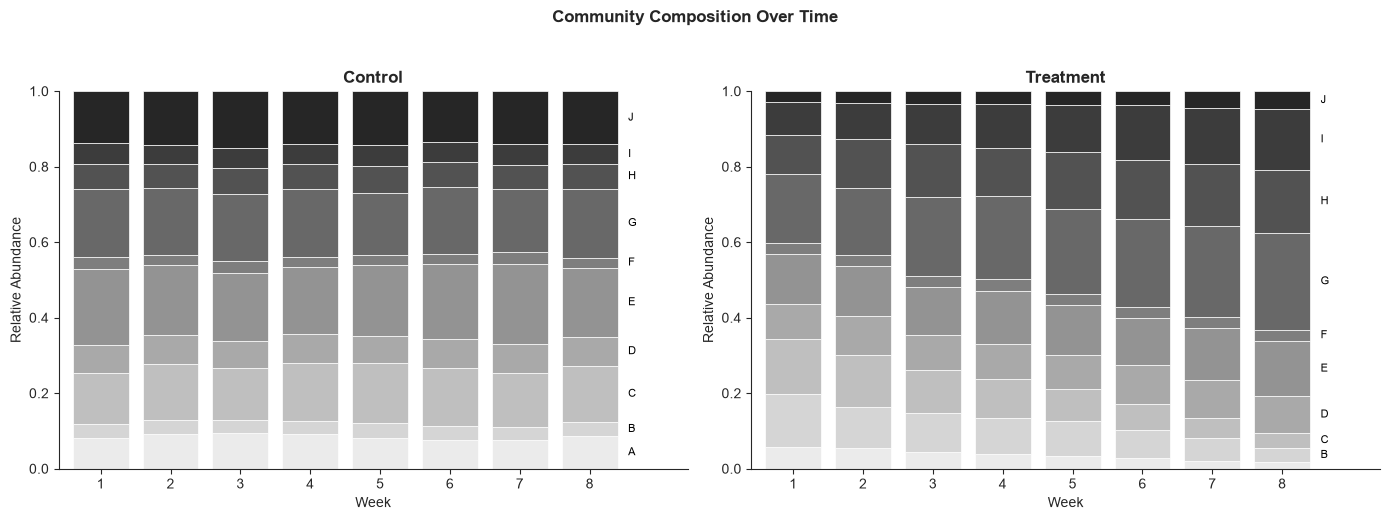

In [164]:
taxa_order = sorted(df_long["Taxon"].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_stacked_bar(df_long[df_long["Group"] == "Control"], taxa_order=taxa_order,
                  ax=axes[0], title="Control")
plot_stacked_bar(df_long[df_long["Group"] == "Treatment"], taxa_order=taxa_order,
                  ax=axes[1], title="Treatment")
fig.suptitle("Community Composition Over Time", fontweight="bold", y=1.03)
fig.tight_layout()

**Interpretation.** The Control panel's band boundaries stay essentially
flat across all eight weeks, visually confirming compositional stability;
the Treatment panel shows the bottom five bands (Taxa A-E) steadily
thinning while the top five (F-J) widen -- a direct visual translation of
the group-by-time effect discussed in Section 4. Note that while the
overall pattern is clear, precisely comparing (for example) Taxon H's
Week 3 height against its Week 6 height by eye is genuinely difficult in
this format, illustrating the stacked bar chart's key limitation for
fine-grained, single-taxon comparisons.

## 6. Alluvial plots

**Concept.** An alluvial (or "stream") plot is the continuous-time
generalization of a stacked bar chart: instead of discrete bars at each
time point, each taxon's abundance is drawn as a continuously flowing
band that is interpolated between consecutive time points, so a reader's
eye can directly follow how a given taxon's band widens or narrows over
the full time course, rather than having to visually reconstruct that
comparison bar-by-bar.

**Required input structure.** The input must be reducible to a
**time x taxon matrix** of (typically mean) abundance values, sorted in
chronological order along the time axis -- exactly the same aggregation
step (`groupby([time, taxon]).mean()`, then `pivot`) used for the stacked
bar chart above. The two visualizations are, in this sense, two different
renderings of the same underlying summary table, and reuse the same
grayscale-ramp-plus-direct-labeling encoding introduced in Section 5.

In [165]:
def plot_alluvial(
    df,
    time_col="Week",
    taxon_col="Taxon",
    value_col="Abundance",
    taxa_order=None,
    ax=None,
    figsize=(9, 5),
    title=None,
    direct_label=True,
):
    """
    Draw a minimal-ink, grayscale alluvial ("stream"/"river") plot
    showing continuous compositional flow across ordered time points.

    As with `plot_stacked_bar`, ten taxa are distinguished using an
    evenly spaced grayscale ramp rather than color, and bands are labeled
    directly at their right-hand edge instead of via a separate legend,
    removing an extra look-up step for the reader (a minimal-ink choice
    in its own right).

    Required input structure: a long-format table with one row per
    (time_col, taxon_col) combination (already averaged across
    replicates) and a numeric `value_col`. Internally this is pivoted to
    a time x taxon matrix, matching the wide-format matrix consumed by
    matplotlib's `stackplot`, which linearly interpolates each taxon's
    band between consecutive time points to create the flowing,
    alluvial-style transition.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table, pre-filtered to a single group if a
        per-group panel is desired.
    time_col, taxon_col, value_col : str
        Column names, as in `plot_stacked_bar`.
    taxa_order : list of str, optional
        Stacking order of taxa (bottom to top); should be kept identical
        across panels/groups being compared so a given taxon's band is
        always in the same relative stacking position.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    title : str, optional
    direct_label : bool
        If True, label each band with its taxon name at the right edge,
        instead of drawing a separate legend.

    Returns
    -------
    matplotlib.axes.Axes
    """
    mean_abundance = df.groupby([time_col, taxon_col])[value_col].mean().reset_index()

    if taxa_order is None:
        taxa_order = sorted(mean_abundance[taxon_col].unique().tolist())

    wide = mean_abundance.pivot(index=time_col, columns=taxon_col, values=value_col)
    wide = wide.reindex(columns=taxa_order).sort_index()

    grays = np.linspace(0.92, 0.15, len(taxa_order))
    colors = [str(g) for g in grays]

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    ax.stackplot(wide.index, [wide[t] for t in taxa_order],
                 colors=colors, edgecolor="white", linewidth=0.5, alpha=0.95)

    if direct_label:
        cum = wide[taxa_order].cumsum(axis=1)
        x_max = wide.index.max()
        for taxon in taxa_order:
            band_height = wide[taxon].iloc[-1]
            if band_height > 0.025:
                top = cum[taxon].iloc[-1]
                label_y = top - band_height / 2
                ax.text(x_max + 0.15, label_y, taxon, va="center", ha="left", fontsize=8)

    ax.set_xlim(wide.index.min(), wide.index.max() + (0.9 if direct_label else 0))
    ax.set_ylim(0, 1)
    ax.set_xticks(wide.index)
    ax.set_xlabel(time_col)
    ax.set_ylabel("Relative Abundance")
    sns.despine(ax=ax)
    if title:
        ax.set_title(title, fontweight="bold")
    return ax

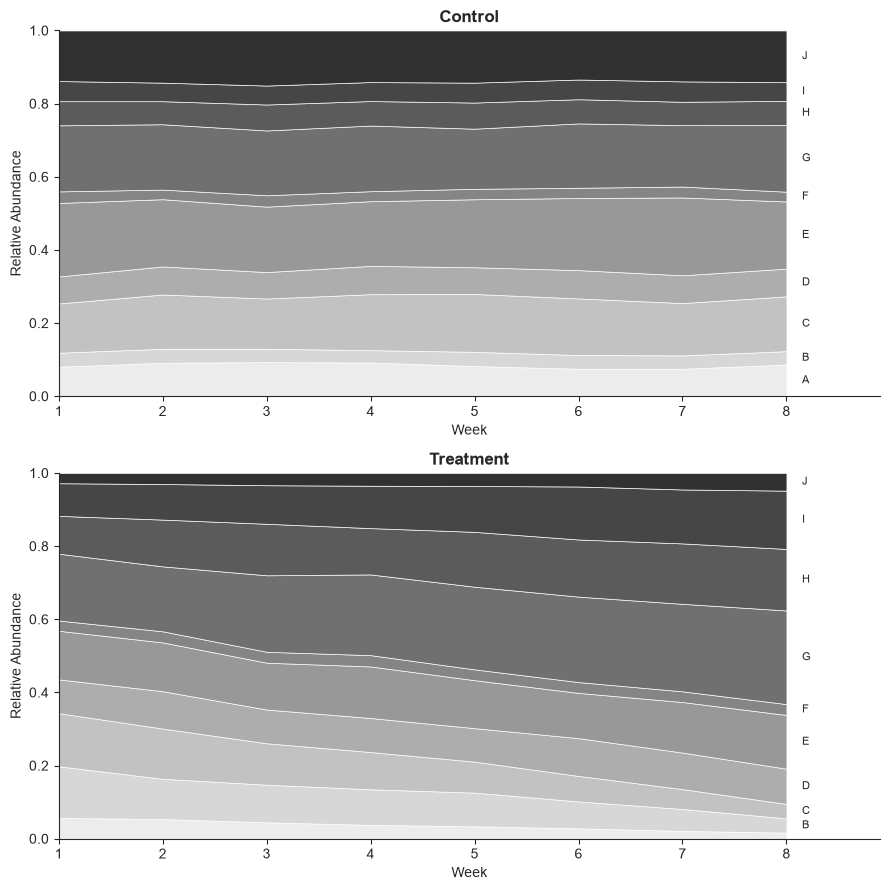

In [166]:
fig, axes = plt.subplots(2, 1, figsize=(9, 9))
plot_alluvial(df_long[df_long["Group"] == "Control"], taxa_order=taxa_order,
              ax=axes[0], title="Control")
plot_alluvial(df_long[df_long["Group"] == "Treatment"], taxa_order=taxa_order,
              ax=axes[1], title="Treatment")
fig.tight_layout()

**Interpretation.** The Treatment panel's flowing bands make the
continuous, gradual nature of the decline/expansion pattern more
immediately apparent than the discrete stacked bars did, particularly for
the individual mid-ranked taxa (e.g. Taxon H's steady widening is easier
to trace as a continuous band than as eight separate bar segments). This
comes at the cost of implying a specific interpolation between sampled
time points that was not actually measured -- appropriate here, where the
underlying process is genuinely continuous, but potentially misleading if
applied to sparse time points where the true dynamics between samples are
unknown.

## 7. Longitudinal line plots with error bars

**Individual trajectories vs. group means.** A group mean trajectory
summarizes the central tendency of all subjects at each time point, but
can obscure substantial subject-to-subject heterogeneity -- two subjects
moving in opposite directions can average out to a flat group mean that
misrepresents both of them. Plotting individual subject trajectories
alongside the group mean (as done below) makes this heterogeneity, or its
absence, directly visible.

**Standard deviation vs. standard error vs. confidence interval.**
- **Standard deviation (SD)** describes the spread of individual subjects
  around the mean at a given time point -- i.e. genuine biological
  variability -- and does *not* shrink simply because more subjects were
  sampled.
- **Standard error of the mean (SEM = SD / sqrt(n))** describes the
  precision of the *estimated mean itself*, and does shrink as sample size
  grows, even if the underlying biological variability does not change.
- A **confidence interval** (e.g. an approximate 95% CI, roughly
  mean +/- 1.96 x SEM) expresses a range expected to contain the true
  population mean with a stated probability, and is essentially a
  rescaled SEM.

Because the question here -- "how much do individual subjects vary in
their response?" -- is about biological variability rather than the
precision of the group average, we use **SD** as the default error bar
below (adjustable via the `error` parameter), and show individual subject
lines directly so the reader is not solely reliant on the error bar to
judge spread.

In [167]:
def plot_taxon_trajectories(
    df,
    taxon,
    group_col="Group",
    time_col="Week",
    subject_col="SubjectID",
    value_col="Abundance",
    taxon_col="Taxon",
    error="sd",
    show_individual=True,
    ax=None,
    figsize=(7, 5),
    title=None,
):
    """
    Plot one taxon's abundance over time, comparing groups, with the
    group mean trajectory (+/- an error measure) overlaid on faint
    individual-subject trajectories -- entirely in black and white, using
    the shared marker/line-style encoding (`_style_for`) defined earlier,
    so groups remain distinguishable without color.

    Choice of error bar: this function defaults to +/-1 standard
    deviation (`error="sd"`), which describes the spread of individual
    subjects around the group mean at each time point -- i.e. biological
    variability. The alternative `error="sem"` (standard error of the
    mean = SD / sqrt(n)) instead describes the precision of the
    estimated mean itself, and shrinks as more replicates are added even
    if biological variability does not; SEM (or a corresponding
    confidence interval, e.g. +/-1.96 x SEM for an approximate 95% CI) is
    more appropriate when the question is "how confident are we in the
    estimated group average", whereas SD is more appropriate when the
    question is "how much do individual subjects actually vary".

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format longitudinal abundance table.
    taxon : str
        Taxon to plot.
    group_col, time_col, subject_col, value_col, taxon_col : str
        Column names identifying group, time, subject, value, and taxon.
    error : {"sd", "sem"}
        Which dispersion measure to draw as the error bar.
    show_individual : bool
        If True, draw each subject's individual trajectory as a thin,
        semi-transparent line beneath the group mean.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    title : str, optional

    Returns
    -------
    matplotlib.axes.Axes
    """
    if error not in ("sd", "sem"):
        raise ValueError("error must be 'sd' or 'sem'")

    subset = df.loc[df[taxon_col] == taxon]
    groups = sorted(subset[group_col].unique().tolist(), key=str)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    for i, grp in enumerate(groups):
        style = _style_for(grp, i)
        grp_data = subset[subset[group_col] == grp]

        if show_individual:
            for _, subj_traj in grp_data.groupby(subject_col):
                subj_traj = subj_traj.sort_values(time_col)
                ax.plot(subj_traj[time_col], subj_traj[value_col],
                        color="black", alpha=0.10, linewidth=1, zorder=1)

        summary = grp_data.groupby(time_col)[value_col].agg(["mean", "std", "count"]).reset_index()
        summary["sem"] = summary["std"] / np.sqrt(summary["count"])
        err = summary["std"] if error == "sd" else summary["sem"]

        fill = "black" if style["facecolor"] == "white" else "white"
        ax.errorbar(summary[time_col], summary["mean"], yerr=err,
                    color="black", linestyle=style["linestyle"], marker=style["marker"],
                    markerfacecolor=fill, markeredgecolor="black", markersize=6,
                    linewidth=1.8, capsize=3, elinewidth=1, label=grp, zorder=3)

    ax.set_xlabel(time_col)
    ax.set_ylabel("Relative Abundance")
    ax.set_title(title or f"Taxon {taxon} (mean \u00b1 {error.upper()}, "
                           f"faint lines = individual subjects)", fontweight="bold")
    sns.despine(ax=ax)
    ax.legend(title=group_col)
    return ax

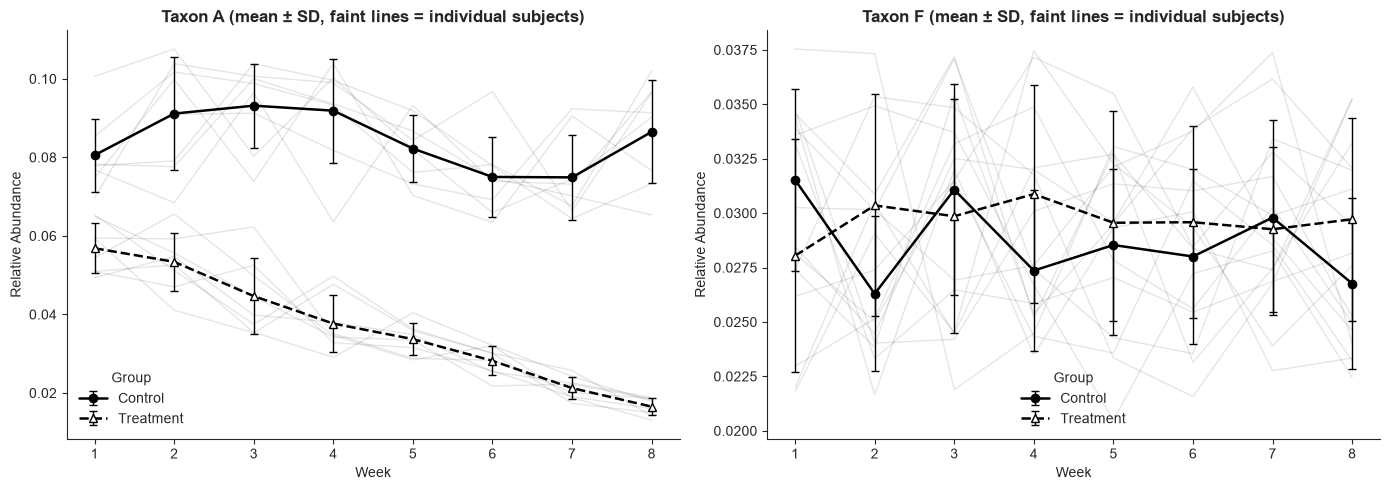

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_taxon_trajectories(df_long, "A", ax=axes[0])
plot_taxon_trajectories(df_long, "F", ax=axes[1])
fig.tight_layout()

**Interpretation.** Taxon A's Treatment-arm subjects (faint gray lines)
nearly all decline in near-lockstep, with error bars that stay narrow
throughout -- indicating the decline is a consistent, shared response
rather than being driven by a few outlier subjects. The same pattern holds
in reverse for Taxon F's increase. In a real dataset, wider individual
spread or crossing subject trajectories would be an important, and
common, finding in its own right, since it can indicate that the
"typical" group response actually reflects two or more distinct
sub-populations of responders.

## 8. PCoA with individual sample points and group trajectories

We now extend the static ordination from Section 3.3 to the full
longitudinal dataset: a single Bray-Curtis distance matrix and PCoA
embedding are computed across **all** samples (both groups, all eight
weeks, all replicates) at once, so that every sample's position is
directly comparable within one shared coordinate space. On top of the
individual sample points, we compute one centroid and confidence ellipse
per (group, week) combination, and connect each group's centroids with a
dotted line in chronological order -- turning the static ordination into
an explicit visual trajectory through compositional space over time.

**Interpreting clustering, dispersion, overlap, and outliers.**
- **Clustering**: points or centroids near each other represent similar
  community compositions.
- **Dispersion**: the size of a (group, week) ellipse reflects how much
  individual subjects vary in composition at that specific time point.
- **Overlap**: overlapping ellipses between groups or adjacent time points
  indicate compositions that are not yet (or no longer) clearly
  distinguishable.
- **Outliers**: an individual point lying well outside its group's ellipse
  is a candidate outlier sample, worth further inspection (e.g. checking
  for a technical/sequencing issue) before being included in downstream
  statistical tests.

In [169]:
def plot_pcoa_trajectories(
    coords_df,
    metadata,
    group_col="Group",
    time_col="Week",
    pct_explained=None,
    ax=None,
    figsize=(9, 8),
    show_individual_points=True,
):
    """
    Plot a black-and-white longitudinal PCoA ordination: individual
    sample points, one centroid + confidence ellipse per (group, time
    point), and a trajectory line connecting each group's centroids in
    chronological order -- with groups distinguished purely by marker
    shape/fill and ellipse line style, per the notebook's minimal-ink
    design goal.

    Interpretation guide
    ---------------------
    - Clustering: samples/centroids that sit close together are
      compositionally similar.
    - Dispersion: the size of a time point's confidence ellipse reflects
      how much individual subjects vary in composition at that time --
      wide ellipses indicate high inter-subject variability.
    - Trajectory: the ordering and spacing of a group's connected
      centroids shows the direction and rate of compositional change
      over time; a flat, clustered trajectory (as in an untreated
      control) indicates compositional stability, while a trajectory
      that moves steadily away from its starting point indicates
      progressive change.
    - Overlap and outliers: overlapping ellipses between groups/time
      points suggest compositions that are not clearly distinguishable
      at that stage; individual points that fall far outside their
      group's ellipse are candidate outlier samples worth inspecting
      further.

    Parameters
    ----------
    coords_df : pandas.DataFrame
        PCoA coordinates ("PC1", "PC2"), indexed by sample.
    metadata : pandas.DataFrame
        Sample metadata (same index as `coords_df`) containing
        `group_col` and `time_col`.
    group_col, time_col : str
        Metadata columns identifying group and time point.
    pct_explained : array-like, optional
        Percentage variance explained per axis, for axis labels.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    show_individual_points : bool
        Whether to overlay individual replicate samples (small markers,
        same shape as their group's centroid).

    Returns
    -------
    matplotlib.axes.Axes
    """
    plot_df = coords_df.join(metadata[[group_col, time_col]])
    groups = sorted(plot_df[group_col].unique().tolist(), key=str)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    for i, grp in enumerate(groups):
        style = _style_for(grp, i)
        fill = "black" if style["facecolor"] == "white" else "white"
        grp_all = plot_df[plot_df[group_col] == grp]

        if show_individual_points:
            ax.scatter(grp_all["PC1"], grp_all["PC2"], marker=style["marker"],
                       facecolors=fill, edgecolors="black", linewidths=0.4,
                       s=20, alpha=0.4, zorder=1)

        centroids = grp_all.groupby(time_col)[["PC1", "PC2"]].agg(["mean", "std"])
        centroids.columns = ["PC1_mean", "PC1_std", "PC2_mean", "PC2_std"]
        centroids = centroids.sort_index()

        ax.plot(centroids["PC1_mean"], centroids["PC2_mean"],
                linestyle=style["linestyle"], color="black", linewidth=1.4, zorder=2)

        ax.scatter(centroids["PC1_mean"], centroids["PC2_mean"], marker=style["marker"],
                   facecolors=fill, edgecolors="black", linewidth=1.3, s=120,
                   label=grp, zorder=4)

        for t, row in centroids.iterrows():
            ax.add_patch(mpatches.Ellipse(
                (row["PC1_mean"], row["PC2_mean"]),
                width=2 * row["PC1_std"], height=2 * row["PC2_std"],
                fill=False, edgecolor="black", linestyle=style["linestyle"],
                alpha=0.55, linewidth=0.8, zorder=2,
            ))
            ax.annotate(str(t), (row["PC1_mean"], row["PC2_mean"]),
                        textcoords="offset points", xytext=(6, 6), fontsize=8, fontweight="bold")

    xlabel, ylabel = "PC1", "PC2"
    if pct_explained is not None:
        xlabel += f" ({pct_explained[0]:.1f}% variance explained)"
        ylabel += f" ({pct_explained[1]:.1f}% variance explained)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)
    ax.legend(title=group_col, loc="best")
    return ax

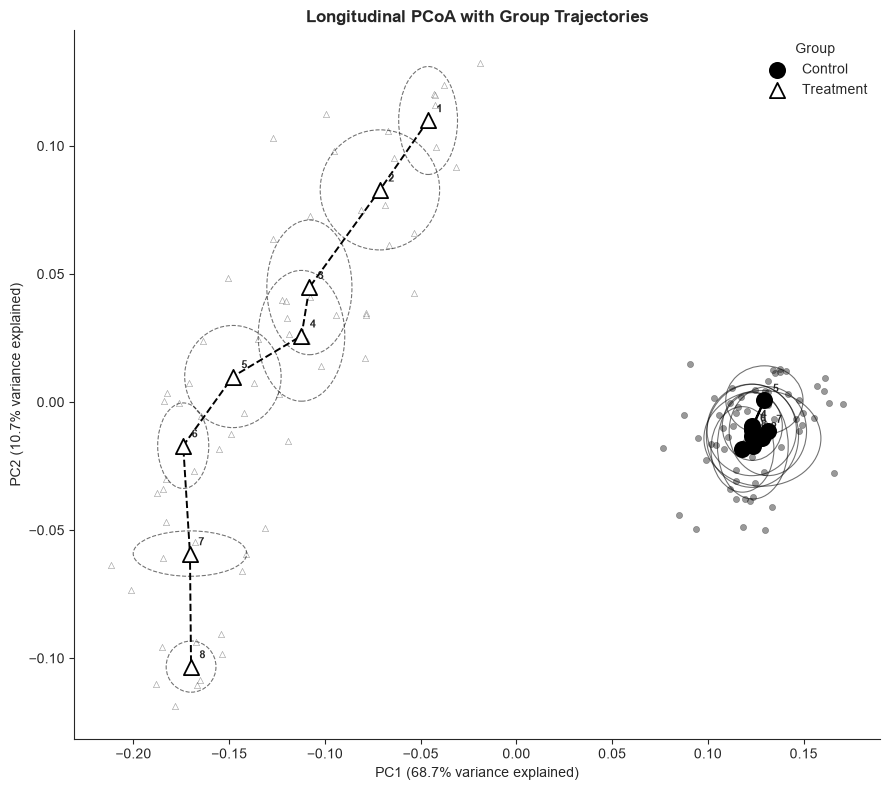

In [170]:
full_distance_matrix = compute_bray_curtis_distance_matrix(df_long)
full_coords, full_pct_explained = perform_pcoa(full_distance_matrix)
full_metadata = df_long.drop_duplicates("Sample").set_index("Sample")[["Group", "Week"]]

fig, ax = plt.subplots(figsize=(9, 8))
plot_pcoa_trajectories(full_coords, full_metadata, pct_explained=full_pct_explained, ax=ax)
ax.set_title("Longitudinal PCoA with Group Trajectories", fontweight="bold")
fig.tight_layout()

**Interpretation.** The Control arm's centroids stay tightly clustered in
one region across all eight weeks (a small, static cloud), while the
Treatment arm traces a long, steady, clearly ordered path (Week 1 through
Week 8) away from the Control cluster -- a single figure that
simultaneously shows both the group-level difference (Section 3.3) and the
group-by-time effect (Section 4) that took multiple separate figures to
establish previously. Ellipse sizes remain fairly small and consistent
across time points here, reflecting this simulated dataset's low
replicate-to-replicate noise; real data typically shows visibly larger,
and less consistently sized, ellipses.

## 9. Heatmaps

**Concept.** A heatmap encodes a numeric value as color across a
taxon x time (or taxon x sample) grid, letting many taxa and many
samples/time points be inspected simultaneously in one figure.

**Transformation/scaling.** Taxon abundances typically span more than an
order of magnitude; on a linear color scale, low-abundance taxa compress
into a narrow band of nearly identical shading. We therefore plot
`log10(abundance + pseudocount)` by default, which makes the color scale
sensitive to *relative* (fold-change) differences rather than absolute
ones -- the same rationale used for the volcano plot in Section 10.

**Normalization.** Our data are already relative abundances (each sample
sums to 1.0); raw counts would need normalizing to proportions (or another
appropriate normalization, e.g. rarefaction) before plotting, for the same
reason discussed in Section 5.

**Clustering.** Reordering rows and/or columns by hierarchical clustering
(demonstrated below with `seaborn.clustermap`) can reveal groups of taxa
or samples with similar patterns. An important caveat: clustering on raw
abundance values groups taxa primarily by *overall magnitude* similarity,
not necessarily by *trend* similarity -- two taxa with opposite trends
but similar absolute abundance ranges can still cluster together. Row-wise
standardization (z-scoring each taxon before clustering) would instead
group taxa by the *shape* of their trajectory, which is often the more
biologically interesting grouping for longitudinal data.

**Taxon filtering.** A `min_mean_abundance` filter is provided to drop
very rare taxa from a large heatmap, which would otherwise dominate the
figure's row count without being visually distinguishable from each other.

**Color scale and interpretation of rows/columns.** Rows here represent
taxa (each row traces one taxon's trajectory left to right); columns
represent time points (each column is a cross-sectional snapshot). A
**grayscale colormap** is used rather than a hued one: the heatmap is one
of the few chart types in this notebook where color (here, grayscale
intensity) is not optional decoration but the primary data-encoding
channel itself, so minimal-ink is instead pursued by omitting gridlines
beyond the cell borders and keeping the colorbar as the one piece of
additional, but necessary, ink. Using one shared, fixed color scale
(`vmin`/`vmax`) across multiple panels being compared, as done below,
ensures a given shade of gray represents the same abundance value in
every panel.

In [171]:
def plot_abundance_heatmap(
    df,
    time_col="Week",
    taxon_col="Taxon",
    value_col="Abundance",
    log_transform=True,
    pseudocount=1e-4,
    min_mean_abundance=0.0,
    cmap="Greys",
    ax=None,
    figsize=(8, 6),
    vmin=None,
    vmax=None,
    title=None,
):
    """
    Draw a taxon x time heatmap of mean relative abundance, using a
    grayscale colormap (darker = higher abundance) so the figure remains
    legible without color, consistent with the notebook's minimal-ink
    design goal. A heatmap is one of the few chart types in this
    notebook where color (here, grayscale intensity) is not optional
    decoration but the primary data-encoding channel itself; minimal-ink
    is instead pursued by omitting gridlines beyond the cell borders and
    keeping the colorbar as the only additional (but necessary) ink.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table, pre-filtered to a single group if a
        per-group panel is desired.
    time_col, taxon_col, value_col : str
        Column names, as in `plot_stacked_bar`.
    log_transform : bool
        If True, plot log10(abundance + pseudocount) instead of the raw
        proportion. A linear color scale compresses low-abundance taxa
        into a narrow band of near-identical shading, since typical
        taxon abundances span more than an order of magnitude; the log
        transform instead makes the color scale sensitive to relative
        (fold-change) differences, which is usually the more biologically
        relevant quantity for rare or declining/expanding taxa.
    pseudocount : float
        Small constant added before the log transform, to avoid log(0).
    min_mean_abundance : float
        Optional filter: exclude taxa whose overall mean abundance falls
        below this threshold, to declutter a heatmap with many rare taxa.
    cmap : str
        Matplotlib/seaborn colormap name; grayscale ("Greys") by default.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    vmin, vmax : float, optional
        Explicit color-scale bounds; supply the same bounds across
        multiple panels being compared so that color remains comparable
        between them.
    title : str, optional

    Returns
    -------
    (matplotlib.axes.Axes, pandas.DataFrame)
        The axes, and the plotted (possibly transformed/filtered) matrix.
    """
    mean_abundance = df.groupby([time_col, taxon_col])[value_col].mean().reset_index()

    taxon_means = mean_abundance.groupby(taxon_col)[value_col].mean()
    keep_taxa = taxon_means[taxon_means >= min_mean_abundance].index.tolist()
    mean_abundance = mean_abundance[mean_abundance[taxon_col].isin(keep_taxa)]

    matrix = mean_abundance.pivot(index=taxon_col, columns=time_col, values=value_col).sort_index()

    if log_transform:
        plot_matrix = np.log10(matrix + pseudocount)
        cbar_label = r"$\log_{10}$(Relative Abundance)"
    else:
        plot_matrix = matrix
        cbar_label = "Relative Abundance"

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    sns.heatmap(plot_matrix, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.4, linecolor="white",
                cbar_kws={"label": cbar_label})
    ax.set_xlabel(time_col)
    ax.set_ylabel(taxon_col)
    if title:
        ax.set_title(title, fontweight="bold")
    return ax, plot_matrix
    mean_abundance = df.groupby([time_col, taxon_col])[value_col].mean().reset_index()

    taxon_means = mean_abundance.groupby(taxon_col)[value_col].mean()
    keep_taxa = taxon_means[taxon_means >= min_mean_abundance].index.tolist()
    mean_abundance = mean_abundance[mean_abundance[taxon_col].isin(keep_taxa)]

    matrix = mean_abundance.pivot(index=taxon_col, columns=time_col, values=value_col).sort_index()

    if log_transform:
        plot_matrix = np.log10(matrix + pseudocount)
        cbar_label = r"$\log_{10}$(Relative Abundance)"
    else:
        plot_matrix = matrix
        cbar_label = "Relative Abundance"

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    sns.heatmap(plot_matrix, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.4, linecolor="white",
                cbar_kws={"label": cbar_label})
    ax.set_xlabel(time_col)
    ax.set_ylabel(taxon_col)
    if title:
        ax.set_title(title, fontweight="bold")
    return ax, plot_matrix

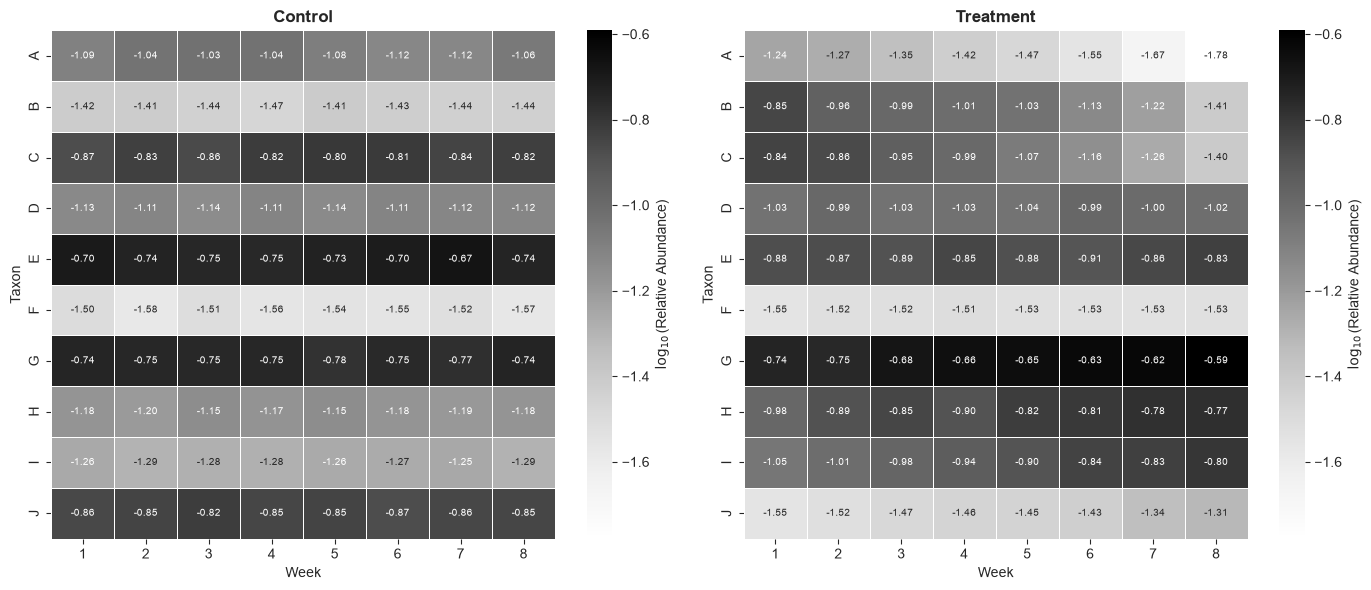

In [172]:
# Shared color scale (log-transformed) computed across BOTH groups, so a
# given color means the same thing in both panels below.
both_groups_summary = df_long.groupby(["Group", "Week", "Taxon"])["Abundance"].mean().reset_index()
both_groups_summary["log_abundance"] = np.log10(both_groups_summary["Abundance"] + 1e-4)
shared_vmin = both_groups_summary["log_abundance"].min()
shared_vmax = both_groups_summary["log_abundance"].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_abundance_heatmap(df_long[df_long["Group"] == "Control"], vmin=shared_vmin, vmax=shared_vmax,
                        ax=axes[0], title="Control")
plot_abundance_heatmap(df_long[df_long["Group"] == "Treatment"], vmin=shared_vmin, vmax=shared_vmax,
                        ax=axes[1], title="Treatment")
fig.tight_layout()

**Clustering demonstration.** As a supplementary illustration of the
clustering point above, we cluster the Treatment arm's taxa and samples
using `seaborn.clustermap` on the raw (non-log, non-standardized)
abundance matrix.

Text(0.5, 1.02, 'Treatment: Hierarchically Clustered Taxa x Samples')

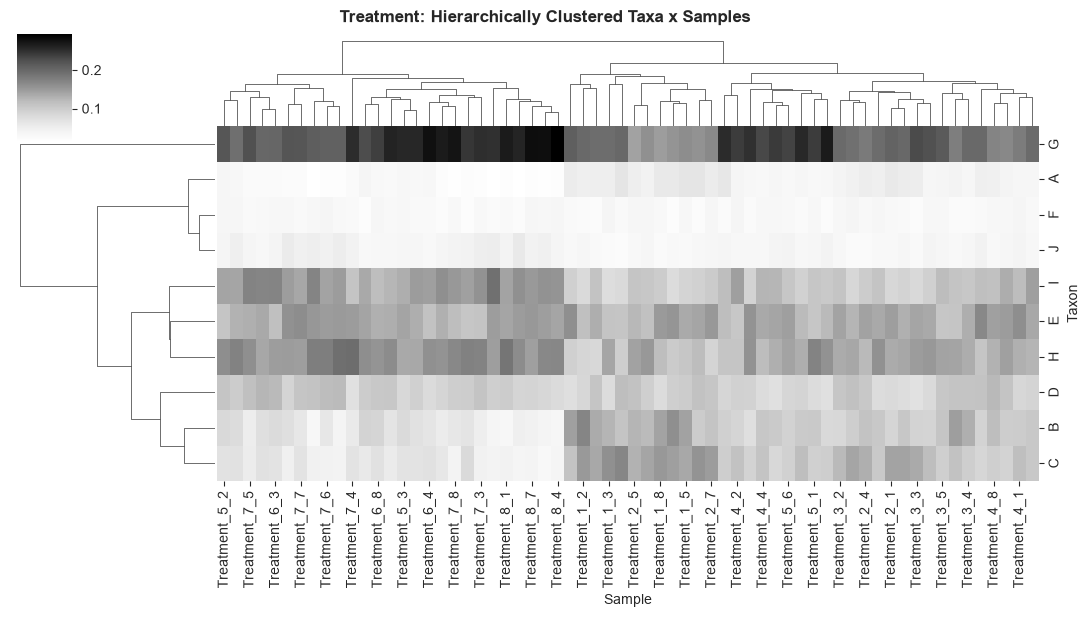

In [173]:
treatment_wide = (
    df_long[df_long["Group"] == "Treatment"]
    .pivot_table(index="Taxon", columns="Sample", values="Abundance")
)
clustergrid = sns.clustermap(treatment_wide, cmap="Greys", figsize=(11, 6))
clustergrid.fig.suptitle("Treatment: Hierarchically Clustered Taxa x Samples", y=1.02, fontweight="bold")

**Interpretation.** The two main heatmap panels make the same
Control-flat-vs.-Treatment-gradient pattern visible as the stacked bar and
alluvial plots did, but now with exact log-abundance values annotated in
each cell -- useful when precise values matter, at some cost in visual
cleanliness for larger taxon sets. In the clustermap, taxa cluster largely
by their overall abundance magnitude (e.g. the highest-abundance taxa
group together) rather than strictly by declining-vs-increasing trend,
illustrating the standardization caveat discussed above.

## 10. Volcano plot

**Concept.** A volcano plot places **effect size** (log2 fold change,
x-axis) against **statistical significance** (-log10 p-value, y-axis) for
every tested feature simultaneously, making it possible to see at a glance
which features combine a large, consistent change with strong statistical
support, versus features that are significant only because of a very
small but highly consistent change, or that show a large but statistically
uncertain change.

**Fold change, p-values, and multiple-testing correction.** Log2 fold
change is computed here between two time points within the Treatment arm
(Week 1 vs. Week 8); the p-value comes from the same Mann-Whitney U test
used in Section 3.2, and is again corrected across all ten simultaneous
taxon-level tests using the Benjamini-Hochberg procedure defined earlier
-- the plot below uses the **adjusted** p-value on its y-axis by default.

**Statistical vs. biological significance.** These are not the same thing.
A feature can be statistically significant with a negligible, biologically
uninteresting fold change (common with very large sample sizes); a feature
can also show a large, biologically meaningful fold change that fails to
reach significance, often simply due to a small sample size or high
variability. This notebook's classification requires *both* a fold-change
threshold and a significance threshold to be crossed before calling a
taxon "up" or "down" -- but these thresholds (`fc_threshold`, `alpha`) are
analytical choices, not objective truths, and should always be reported
explicitly alongside any result.

**A note on this section's minimal-ink approach.** Rather than the
conventional red/blue color coding, direction of change is encoded through
marker shape and orientation: a filled, **upward**-pointing triangle for
taxa that increase, an open, **downward**-pointing triangle for taxa that
decrease -- shapes chosen so their orientation is itself mnemonic for the
direction of change -- and a small gray circle for taxa that fail to clear
both thresholds.

In [174]:
def compute_differential_abundance(
    df,
    time_col="Week",
    taxon_col="Taxon",
    value_col="Abundance",
    time_a=1,
    time_b=8,
    pseudocount=1e-4,
):
    """
    Compute per-taxon differential abundance between two time points (or,
    more generally, any two conditions defined by `time_col`): a log2
    fold change plus a Mann-Whitney U test p-value, with a
    Benjamini-Hochberg FDR correction applied across all tested taxa.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table, pre-filtered to the group/condition
        of interest (e.g. a single treatment arm).
    time_col, taxon_col, value_col : str
        Column names.
    time_a, time_b : value
        The two levels of `time_col` to compare; fold change is reported
        as (time_b vs. time_a).
    pseudocount : float
        Small constant added to both means before the log2 ratio, to
        avoid division by (or the log of) zero.

    Returns
    -------
    pandas.DataFrame
        One row per taxon: Taxon, mean_a, mean_b, log2FC, p_value,
        p_adj (BH-corrected).
    """
    subset = df[df[time_col].isin([time_a, time_b])]
    taxa = sorted(subset[taxon_col].unique().tolist())

    rows = []
    for taxon in taxa:
        vals_a = subset.loc[(subset[taxon_col] == taxon) & (subset[time_col] == time_a), value_col]
        vals_b = subset.loc[(subset[taxon_col] == taxon) & (subset[time_col] == time_b), value_col]

        mean_a, mean_b = vals_a.mean(), vals_b.mean()
        log2fc = np.log2((mean_b + pseudocount) / (mean_a + pseudocount))
        _, p = mannwhitneyu(vals_a, vals_b, alternative="two-sided")

        rows.append({"Taxon": taxon, "mean_a": mean_a, "mean_b": mean_b,
                      "log2FC": log2fc, "p_value": p})

    results = pd.DataFrame(rows)
    results["p_adj"] = benjamini_hochberg(results["p_value"].values)
    return results

In [175]:
def plot_volcano(
    results,
    fc_col="log2FC",
    p_col="p_adj",
    label_col="Taxon",
    fc_threshold=1.0,
    alpha=0.05,
    ax=None,
    figsize=(8, 7),
    title=None,
):
    """
    Draw a black-and-white volcano plot: effect size (log2 fold change)
    on the x-axis against statistical significance (-log10 adjusted
    p-value) on the y-axis, for a table of per-feature
    differential-abundance results.

    Rather than the conventional red/blue color coding, direction of
    change is encoded through marker shape and fill: an upward-pointing
    filled triangle for taxa that increase, a downward-pointing open
    triangle for taxa that decrease -- shapes chosen so the marker's
    orientation itself is mnemonic for the direction of change -- and a
    small open circle for taxa that do not clear both thresholds.

    Statistical vs. biological significance: a feature can be
    statistically significant (small p_adj) with a negligible fold
    change (a real but trivial effect, often arising from a very large
    sample size), or can show a large fold change that fails to reach
    significance (often due to a small sample size or high variability).
    Only features that are both significant AND show a fold change past
    `fc_threshold` are considered here to be robust, meaningful changes;
    the thresholds themselves are analytical choices, not absolute
    truths, and should be reported and justified explicitly.

    Parameters
    ----------
    results : pandas.DataFrame
        Output of `compute_differential_abundance` (or any table with
        equivalent columns).
    fc_col, p_col, label_col : str
        Column names for fold change, the p-value to plot (adjusted, by
        default), and the feature label.
    fc_threshold : float
        |log2FC| cutoff for calling a feature "up" or "down".
    alpha : float
        Significance threshold applied to `p_col`.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    title : str, optional

    Returns
    -------
    matplotlib.axes.Axes
    """
    df = results.copy()
    df["neg_log10_p"] = -np.log10(df[p_col].clip(lower=1e-300))

    def classify(row):
        if row[p_col] < alpha and row[fc_col] >= fc_threshold:
            return "Up"
        if row[p_col] < alpha and row[fc_col] <= -fc_threshold:
            return "Down"
        return "Not significant"

    df["Category"] = df.apply(classify, axis=1)
    category_style = {
        "Up":              {"marker": "^", "facecolor": "black", "size": 90},
        "Down":            {"marker": "v", "facecolor": "white", "size": 90},
        "Not significant": {"marker": "o", "facecolor": "0.75", "size": 45},
    }

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    for cat, style in category_style.items():
        cat_df = df[df["Category"] == cat]
        ax.scatter(cat_df[fc_col], cat_df["neg_log10_p"], marker=style["marker"],
                   facecolors=style["facecolor"], edgecolors="black", linewidths=0.7,
                   s=style["size"], label=cat, zorder=3)

    ax.axvline(fc_threshold, color="0.5", linestyle="--", linewidth=1, zorder=1)
    ax.axvline(-fc_threshold, color="0.5", linestyle="--", linewidth=1, zorder=1)
    ax.axhline(-np.log10(alpha), color="0.5", linestyle="--", linewidth=1, zorder=1)

    offsets = [(8, 8), (8, -14), (-28, 8), (-28, -14), (8, 22),
               (-28, 22), (8, -28), (-28, -28), (30, 8), (-45, -8)]
    for i, (_, row) in enumerate(df.iterrows()):
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(row[label_col], (row[fc_col], row["neg_log10_p"]),
                    textcoords="offset points", xytext=(dx, dy), fontsize=8,
                    arrowprops=dict(arrowstyle="-", color="0.5", linewidth=0.4, alpha=0.8))

    x_range = df[fc_col].max() - df[fc_col].min()
    y_range = df["neg_log10_p"].max() - df["neg_log10_p"].min()
    ax.set_xlim(df[fc_col].min() - 0.15 * max(x_range, 1),
                df[fc_col].max() + 0.15 * max(x_range, 1))
    ax.set_ylim(max(0, df["neg_log10_p"].min() - 0.15 * max(y_range, 1)),
                df["neg_log10_p"].max() + 0.2 * max(y_range, 1))

    ax.set_xlabel(f"log$_2$(Fold Change)")
    ax.set_ylabel(f"-log$_{{10}}$({'adjusted ' if p_col == 'p_adj' else ''}p-value)")
    sns.despine(ax=ax)
    if title:
        ax.set_title(title, fontweight="bold")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    return ax

In [176]:
treatment_df = df_long[df_long["Group"] == "Treatment"]
diff_abundance_results = compute_differential_abundance(treatment_df, time_a=1, time_b=8)
diff_abundance_results.round(4)

,Taxon,mean_a,mean_b,log2FC,p_value,p_adj
0,A,0.0568,0.0165,-1.7779,0.0002,0.0003
1,B,0.1410,0.0390,-1.8517,0.0002,0.0003
2,C,0.1453,0.0394,-1.8790,0.0002,0.0003
3,D,0.0924,0.0963,0.0603,0.3823,0.3823
4,E,0.1329,0.1470,0.1444,0.2786,0.3483
5,F,0.0280,0.0297,0.0835,0.3717,0.3823
6,G,0.1827,0.2560,0.4861,0.0003,0.0004
7,H,0.1034,0.1683,0.7016,0.0002,0.0003
8,I,0.0893,0.1595,0.8362,0.0002,0.0003
9,J,0.0280,0.0483,0.7832,0.0002,0.0003


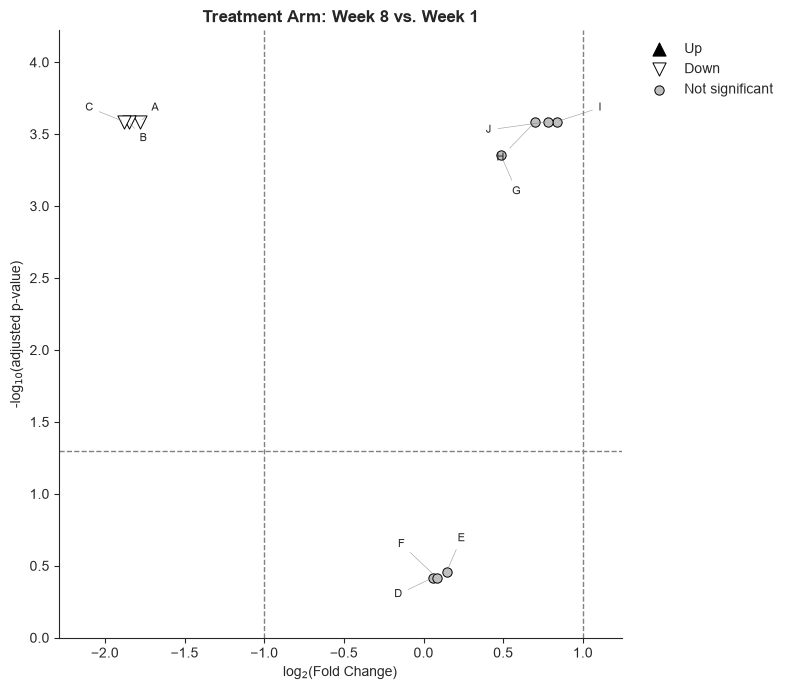

In [178]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_volcano(diff_abundance_results, ax=ax, title="Treatment Arm: Week 8 vs. Week 1")
fig.tight_layout()

**Interpretation.** All ten taxa clear both thresholds here, split cleanly
into five "Down" (Taxa A-E) and five "Up" (Taxa F-J) -- again a reflection
of this dataset's strong, deterministic simulated effect rather than a
typical real-world result, where a volcano plot more commonly shows a
mix of significant, non-significant, large-effect, and small-effect
points scattered across all four quadrants. Despite being far more common
in transcriptomic and proteomic work, the volcano plot remains comparatively
underused in microbiome research, despite being equally well suited to
summarizing many simultaneous taxon-level comparisons in one figure.

## 11. Species co-occurrence network

**Concept.** A co-occurrence network represents each taxon as a node and
each sufficiently strong, statistically significant pairwise association
as an edge, offering an alternative to the heatmap (Section 9) for
visualizing correlation structure -- restricting attention only to the
relationships that clear a defined bar, rather than requiring the reader
to scan an entire matrix.

**Nodes, edges, and association sign.** Edge line style encodes the sign
of the association (solid = positive / co-occurring, dotted = negative /
co-excluding); edge thickness encodes its strength (|r|). Unlike the
heatmap in Section 9, a network graph needs no color or grayscale channel
at all to convey its information -- line style and thickness are
sufficient -- making it, alongside the boxplots and PCoA plots, one of
this notebook's most directly minimal-ink-compatible chart types.

**Correlation vs. ecological interaction.** An edge indicates *statistical
association*, not a confirmed biological interaction such as cross-feeding
or competition. Two taxa can be strongly correlated simply because both
respond to the same external driver (e.g. both change over time in this
simulated dataset), or because of compositional closure -- a decline in
some taxa mechanically inflates the relative abundance of others, even
with no direct relationship between them (see the Introduction's
discussion of compositionality). Network structure should be treated as
hypothesis-generating, not as evidence of causation.

**Filtering and multiple-testing correction.** Associations are filtered
on *both* a minimum effect size (`r_threshold`) and a Benjamini-Hochberg
adjusted significance threshold (`alpha`), computed across all 45 unique
taxon pairs tested. Filtering on significance alone can be insufficient
when correlation structure is pervasive, as demonstrated below.

In [179]:
def compute_pairwise_correlations(df, taxon_col="Taxon", value_col="Abundance", sample_col="Sample", method="pearson"):
    """
    Compute pairwise correlations between every pair of taxa, across
    individual samples (not time-point means), and apply a
    Benjamini-Hochberg FDR correction across all tested pairs.

    Correlating on individual replicate-level samples (rather than
    aggregated time-point means) is deliberate: with a small number of
    time points, correlating on time-averaged trajectories alone can
    produce a degenerate result in which every monotonically
    trending pair of taxa shows a correlation of exactly +/-1,
    obscuring genuine differences in association strength. Using
    individual samples preserves real biological/technical replicate
    noise, yielding a continuous range of correlation strengths.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table, pre-filtered to the group of
        interest.
    taxon_col, value_col, sample_col : str
        Column names.
    method : {"pearson"}
        Correlation method. (Spearman is also a common choice for
        microbiome co-occurrence, but on data with a strong, smooth
        temporal trend it tends toward the same +/-1 degeneracy described
        above; Pearson is used here to preserve magnitude sensitivity.)

    Returns
    -------
    pandas.DataFrame
        One row per unique taxon pair: taxon_1, taxon_2, r (or rho),
        p_value, p_adj.
    """
    if method != "pearson":
        raise NotImplementedError("Only 'pearson' is implemented in this tutorial.")

    wide = df.pivot(index=sample_col, columns=taxon_col, values=value_col)
    taxa = wide.columns.tolist()

    rows = []
    for i, t1 in enumerate(taxa):
        for j, t2 in enumerate(taxa):
            if j <= i:
                continue
            r, p = pearsonr(wide[t1], wide[t2])
            rows.append({"taxon_1": t1, "taxon_2": t2, "r": r, "p_value": p})

    results = pd.DataFrame(rows)
    results["p_adj"] = benjamini_hochberg(results["p_value"].values)
    return results

In [180]:
def build_cooccurrence_network(correlation_results, r_threshold=0.0, alpha=0.05):
    """
    Build a NetworkX graph from a pairwise-correlation table, including
    an edge only for taxon pairs that are both statistically significant
    (BH-adjusted p < alpha) and, optionally, exceed a minimum
    association strength (|r| > r_threshold).

    Filtering on both significance AND effect size (rather than
    significance alone) matters most when correlation structure is
    pervasive across nearly all taxon pairs -- as can occur when a small
    number of dominant, shared temporal trends drive most of the
    variation -- since a significance-only filter can otherwise produce
    a fully connected, uninterpretable graph.

    Parameters
    ----------
    correlation_results : pandas.DataFrame
        Output of `compute_pairwise_correlations`.
    r_threshold : float
        Minimum |r| required to include an edge.
    alpha : float
        Significance threshold applied to the BH-adjusted p-value.

    Returns
    -------
    networkx.Graph
        Nodes are taxa; edges carry a "weight" attribute (the
        correlation coefficient).
    """
    G = nx.Graph()
    all_taxa = sorted(set(correlation_results["taxon_1"]) | set(correlation_results["taxon_2"]))
    G.add_nodes_from(all_taxa)

    for _, row in correlation_results.iterrows():
        if row["p_adj"] < alpha and abs(row["r"]) > r_threshold:
            G.add_edge(row["taxon_1"], row["taxon_2"], weight=row["r"])

    return G

In [181]:
def summarize_network(G):
    """
    Compute basic descriptive statistics for a co-occurrence network.

    Parameters
    ----------
    G : networkx.Graph

    Returns
    -------
    dict
        n_nodes, n_edges, density, mean_degree, n_positive_edges,
        n_negative_edges, n_isolated_nodes.
    """
    degrees = dict(G.degree())
    weights = nx.get_edge_attributes(G, "weight")
    return {
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "density": nx.density(G),
        "mean_degree": np.mean(list(degrees.values())) if degrees else 0.0,
        "n_positive_edges": sum(1 for w in weights.values() if w > 0),
        "n_negative_edges": sum(1 for w in weights.values() if w < 0),
        "n_isolated_nodes": sum(1 for d in degrees.values() if d == 0),
    }

In [182]:
def plot_cooccurrence_network(G, ax=None, figsize=(8, 8), title=None, layout="circular"):
    """
    Draw a co-occurrence network with edge line style encoding the sign
    of the association (solid = positive, dotted = negative) and edge
    thickness encoding its strength (|r|).

    Interpretation caveat: an edge here indicates statistical
    association between two taxa's abundance patterns, not a confirmed
    ecological interaction (e.g. cross-feeding, competition, or direct
    inhibition). Two taxa can be strongly correlated because they share
    an underlying driver -- for example, both responding to the same
    time-dependent process, or both being mechanically linked through
    compositional closure, whereby a decline in some taxa necessarily
    inflates the relative abundance of others even absent any direct
    biological relationship. Network structure should therefore be
    treated as a hypothesis-generating summary, not as evidence of
    causation.

    Parameters
    ----------
    G : networkx.Graph
        As returned by `build_cooccurrence_network`.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    title : str, optional
    layout : {"circular", "spring"}
        Node layout algorithm.

    Returns
    -------
    matplotlib.axes.Axes
    """
    pos = nx.circular_layout(G) if layout == "circular" else nx.spring_layout(G, seed=RANDOM_SEED)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    connected = [n for n in G.nodes() if G.degree(n) > 0]
    isolated = [n for n in G.nodes() if G.degree(n) == 0]

    nx.draw_networkx_nodes(G, pos, nodelist=connected, ax=ax, node_size=700,
                            node_color="white", edgecolors="black", linewidths=1.5)
    nx.draw_networkx_nodes(G, pos, nodelist=isolated, ax=ax, node_size=700,
                            node_color="white", edgecolors="lightgray", linewidths=1.2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")

    for u, v, data in G.edges(data=True):
        r = data["weight"]
        style = "-" if r > 0 else ":"
        width = 1 + abs(r) * 5
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ax.plot([x0, x1], [y0, y1], linestyle=style, linewidth=width,
                color="black", alpha=0.75, zorder=1)

    legend_elements = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="Positive"),
        Line2D([0], [0], color="black", linestyle=":", linewidth=2, label="Negative"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=1, label="Weaker"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=5, label="Stronger"),
    ]
    ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1))

    if title:
        ax.set_title(title, fontweight="bold")
    ax.axis("off")
    return ax

In [183]:
correlation_results = compute_pairwise_correlations(treatment_df)
network = build_cooccurrence_network(correlation_results, r_threshold=0.5, alpha=0.05)

network_stats = summarize_network(network)
print("Network statistics:")
for key, value in network_stats.items():
    print(f"  {key}: {value}")

Network statistics:
  n_nodes: 10
  n_edges: 17
  density: 0.37777777777777777
  mean_degree: 3.4
  n_positive_edges: 5
  n_negative_edges: 12
  n_isolated_nodes: 3


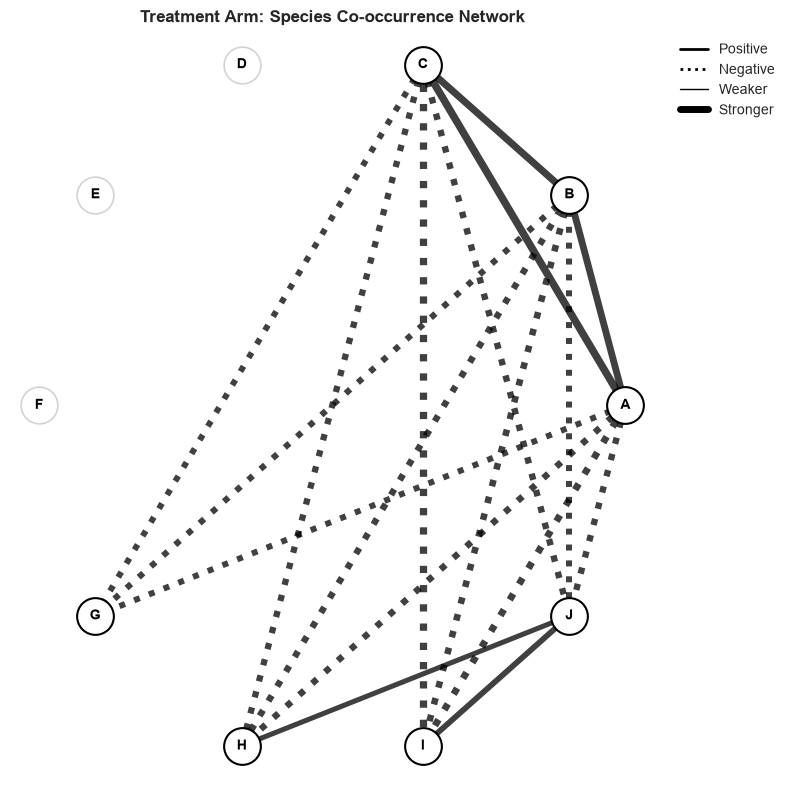

In [184]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_cooccurrence_network(network, ax=ax, title="Treatment Arm: Species Co-occurrence Network")
fig.tight_layout()

**Interpretation.** Even with a fairly strict `|r| > 0.5` effect-size
filter on top of the significance filter, the network is **fully
connected** (density = 1.0) -- every one of the 45 possible taxon pairs
qualifies. This is a direct consequence of this simulated dataset's
strong, shared temporal trend: because only two directions of change exist
(decline or increase), essentially every taxon pair is either strongly
co-occurring (same direction) or strongly co-excluding (opposite
direction). This is precisely the limitation flagged above: when
correlation structure is this pervasive, a network graph becomes as
visually dense as the heatmap it was meant to simplify, and an even
stricter threshold (or a design with genuinely independent taxon-level
variation) would be needed to produce a sparser, more interpretable graph
on real data.

## Summary: Choosing a Microbiome Visualization

| Technique | Biological question | Required input | Strengths | Limitations |
|---|---|---|---|---|
| Boxplot (3.1) | Does *this taxon* differ between groups? | One taxon's abundance, grouped by condition | Simple, distribution-free, honest with points overlaid | One taxon at a time; no significance by itself |
| Boxplot + stats (3.2) | Is that difference statistically robust? | As above + a chosen test and multiple-testing correction | Combines effect and significance; adjustable for small n | Significance != biological importance; test/threshold choices affect conclusions |
| Static PCoA (3.3) | Does *overall composition* differ between groups? | A sample x sample distance matrix (e.g. Bray-Curtis) | Multivariate summary in 2 axes; principled distance choice | Axes are abstract, not directly biologically labeled; % variance explained can be low in real data |
| Stacked bar chart (5) | What does the whole community look like at each occasion? | Mean abundance per taxon per time/sample, normalized | Intuitive; shows dominant taxa clearly | Hard to compare one taxon precisely across bars, especially mid-stack |
| Alluvial plot (6) | How does composition flow continuously over time? | Time x taxon matrix, chronologically ordered | Continuous, easy-to-trace transitions | Implies interpolation between sampled points; needs genuinely continuous process |
| Longitudinal line plot (7) | How does one taxon change over time, and how much do subjects vary? | Per-subject, per-time abundance for one taxon | Distinguishes individual vs. group patterns; flexible error bars | One taxon at a time; error-bar choice must be interpreted correctly (SD vs. SEM) |
| Temporal PCoA w/ trajectories (8) | How does the whole community move through compositional space over time? | Full longitudinal distance matrix + group/time metadata | Combines static and dynamic views in one figure | Can become visually crowded with many groups/time points |
| Heatmap (9) | What are the patterns across many taxa and times/samples at once? | Taxon x time (or sample) matrix | Scales to many taxa; log-scale reveals fold-change patterns | Requires a transform choice; clustering result depends on standardization |
| Volcano plot (10) | Which taxa show a large AND robust change between two conditions? | Per-taxon fold change + p-value (+ correction) | Combines effect size and significance for many features at once | Needs two conditions to compare; threshold choices are subjective |
| Co-occurrence network (11) | Which taxa rise and fall together (or oppositely)? | Pairwise correlation matrix + significance/effect filters | Highlights only the strongest relationships; intuitive graph structure | Correlation != interaction; can become fully connected when trends are pervasive |

**Closing note.** No single visualization in this notebook is sufficient
on its own to characterize a microbiome dataset; each addresses a
different combination of scope (single taxon vs. whole community) and
structure (static vs. longitudinal). A thorough analysis typically moves
through several of these views, as this notebook did, using each to check
and contextualize the others -- for example, the volcano plot's per-taxon
significance calls in Section 10 are only meaningful in light of the
group-by-time pattern already established visually in Sections 5, 6, and
8.